*<small>Last updated: 2026-08-16 21:06:59 UTC | Student Version (No Solutions)</small>*

# Linear Regression: Pipelines, Regularization, and Online Learning

**Course**: Machine Learning Labs  
**Lab**: 01 — Linear Regression  

---

## Table of Contents

1. [Setup and Imports](#setup)
2. [Introduction](#intro)
3. [Part 1 — Sklearn Pipelines with Ridge Regression](#part1)
   - 3.1 [Dataset: California Housing](#data1)
   - 3.2 [Why Pipelines?](#pipelines)
   - 3.3 [Building the Ridge Pipeline](#build)
   - 3.4 [Hyperparameter Tuning with GridSearchCV](#gridsearch)
   - 3.5 [Model Evaluation](#eval1)
   - [Exercise 1.1 — Effect of Polynomial Degree](#ex11)
   - [Exercise 1.2 — Ridge vs. Lasso](#ex12)
4. [Part 2 — Online Learning with SGDRegressor](#part2)
   - 4.1 [When Data Doesn't Fit in Memory](#scale)
   - 4.2 [Dataset: Year Prediction MSD](#data2)
   - 4.3 [SGDRegressor and `partial_fit`](#sgd)
   - [Exercise 2.1 — Implement the Mini-Batch Training Loop](#ex21)
   - [Exercise 2.2 — Plot the Convergence Curve](#ex22)
   - [Exercise 2.3 — Multi-Epoch Training](#ex23)
   - [Exercise 2.4 — Learning Rate Exploration](#ex24)
   - [Exercise 2.5 — Learning Rate Schedules](#ex25)
5. [Real-World Considerations](#realworld)
6. [Summary and Key Takeaways](#summary)

---

**Estimated Time**: 3–4 hours  
**Prerequisites**: Python, NumPy, Pandas, introductory supervised learning



## 📔 Resolution

   After the deadline, you will find the resolution at the following Notion link:

https://app.notion.com/p/R-Reg-lineal-python-intro-2780573743578010af37de77f8e24bee?source=copy_link

   Remember that there are several ways to solve the proposed activities in the labs.
   Use the provided resolution as a reference. If the resolution link is not public,
   request access at the same Notion link.

## 🚚 Deliverables

**Don't forget to duplicate this notebook to be able to edit: File -> Save a copy in Drive**

In this lab, you do not need to write a report in a separate document. Please complete all required
activities within this Google Colab notebook. Remember that a notebook allows you to enter text
elements similarly to a document processor. Once the proposed activities are completed, you must
submit the following on the platform:

1. A PDF file generated in Google Colab from the menu "File" -> "Print".

2. The public Google Colab link. To do so, go to the share button and change the sharing settings
   to "Anyone with the link".


---
<a id='setup'></a>
## 1. Setup and Imports


In [1]:
# Install / upgrade packages when running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    import subprocess
    subprocess.run(['pip', 'install', '--quiet', '--upgrade',
                    'scikit-learn>=1.3', 'seaborn>=0.12'], check=True)
    print('Colab environment ready.')
except ImportError:
    IN_COLAB = False
    print('Local environment detected.')


Local environment detected.


In [2]:
import os
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, SGDRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

warnings.filterwarnings('ignore')

scikit-learn : 1.9.1
NumPy        : 2.5.3
Pandas       : 3.0.6


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Part 1: Pipeline / GridSearch ────────────────────────────────────────────
TEST_SIZE  = 0.2
CV_FOLDS   = 5
POLY_DEGREE = 3          # Exercise 1.1: try 1 or 3
ALPHAS     = np.logspace(-4, 4, 30)

# ── Part 2: Online Learning ───────────────────────────────────────────────────
CHUNK_SIZE     = 5_000
N_EPOCHS       = 10
MSD_TRAIN_ROWS = 463_715   # official UCI split: first 463,715 rows are training
MSD_TEST_ROWS  = 51_630    # last 51,630 rows are test (total = 515,345)
MSD_DATA_FILE  = 'YearPredictionMSD.txt'
MSD_URL        = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
                  '/00203/YearPredictionMSD.txt.zip')

# ── Plotting defaults ─────────────────────────────────────────────────────────
os.makedirs('assets', exist_ok=True)
plt.rcParams.update({
    'figure.figsize'   : (11, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
COLORS = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

print('Configuration ready.')

Configuration ready.


---
<a id='intro'></a>
## 2. Introduction

Linear regression is the foundation of supervised machine learning. Despite its simplicity, it remains one of the most widely deployed models in industry — from predicting house prices to forecasting energy demand. Mastering it means mastering the core ideas that every more complex model builds on: loss functions, gradient descent, regularization, and generalization.

This lab covers two perspectives on linear regression:

**Part 1 — Sklearn Pipelines with Ridge Regression** (instructor walkthrough)  
You will build a complete machine-learning pipeline that chains polynomial feature expansion, feature scaling, and Ridge regression. You will use `GridSearchCV` to tune the regularization strength λ (alpha) and visualize the classic bias–variance tradeoff through a train/validation error curve.

**Part 2 — Online Learning with SGDRegressor** (student activity)  
You will train a linear model on a dataset that is too large to hold in memory at once — the **Year Prediction MSD** dataset, a subset of the Million Song Dataset with 515 K songs and 90 audio features. You will use `SGDRegressor.partial_fit` to process the data in mini-batches, monitor convergence, and experimentally discover how the learning rate drives convergence or catastrophic divergence.

### Learning Objectives

By the end of this lab you will be able to:

1. Explain why preprocessing steps must be wrapped in a `Pipeline` to prevent data leakage during cross-validation.
2. Build a multi-step sklearn `Pipeline` combining feature engineering, scaling, and a regularized estimator.
3. Use `GridSearchCV` to perform principled hyperparameter search and interpret the resulting validation curve.
4. Describe the difference between batch, stochastic, and mini-batch gradient descent.
5. Implement online / incremental learning with `SGDRegressor.partial_fit` on chunked data.
6. Diagnose learning-rate divergence and understand the role of learning-rate schedules.


---
<a id='part1'></a>
## 3. Part 1 — Sklearn Pipelines with Ridge Regression

<a id='data1'></a>
### 3.1 Dataset: California Housing

We use the **California Housing** dataset, derived from the 1990 US Census. Each row represents one census block group; the task is to predict the **median house value** (in units of \$100,000).

| Feature | Description |
|---------|-------------|
| `MedInc` | Median household income in block |
| `HouseAge` | Median house age in block |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Block population |
| `AveOccup` | Average occupancy per household |
| `Latitude` | Block latitude |
| `Longitude` | Block longitude |

**Target**: `MedHouseVal` — median house value in \$100 K (range 0.15 – 5.0).


In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f'Samples  : {df.shape[0]:,}')
print(f'Features : {X.shape[1]}')
print(f'Target   : MedHouseVal  min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}')
print()
display(df.describe().round(2))


Samples  : 20,640
Features : 8
Target   : MedHouseVal  min=0.15  max=5.00  mean=2.07



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


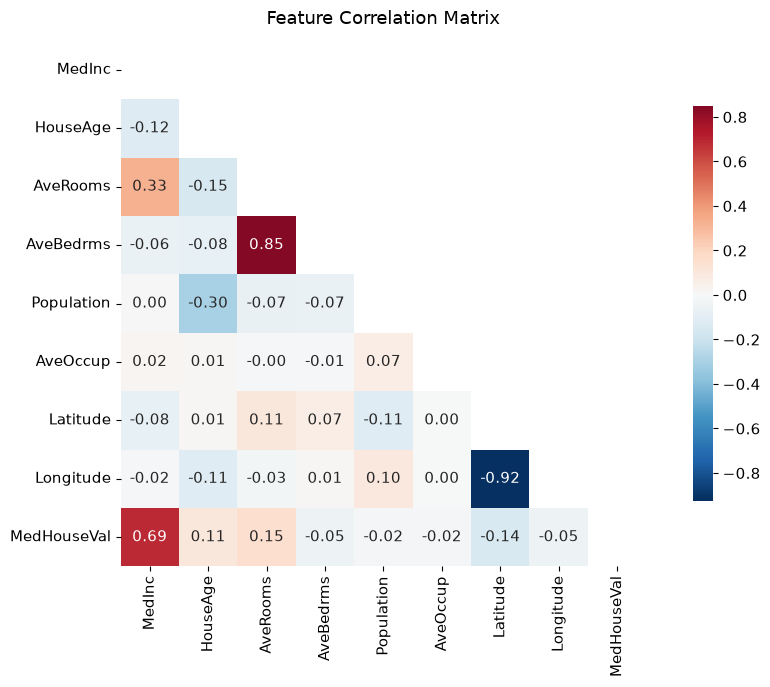

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, ax=ax,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.savefig('assets/california_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusion from the correlation matrix**: `MedInc` (median income) has the highest correlation with the target (`MedHouseVal`) at **≈ 0.69**, well above the next strongest predictor `AveRooms` (≈ 0.15 after accounting for sign). The scatter plot below focuses on this dominant feature and reveals a non-linear curve — motivating polynomial feature expansion in Section 3.3.

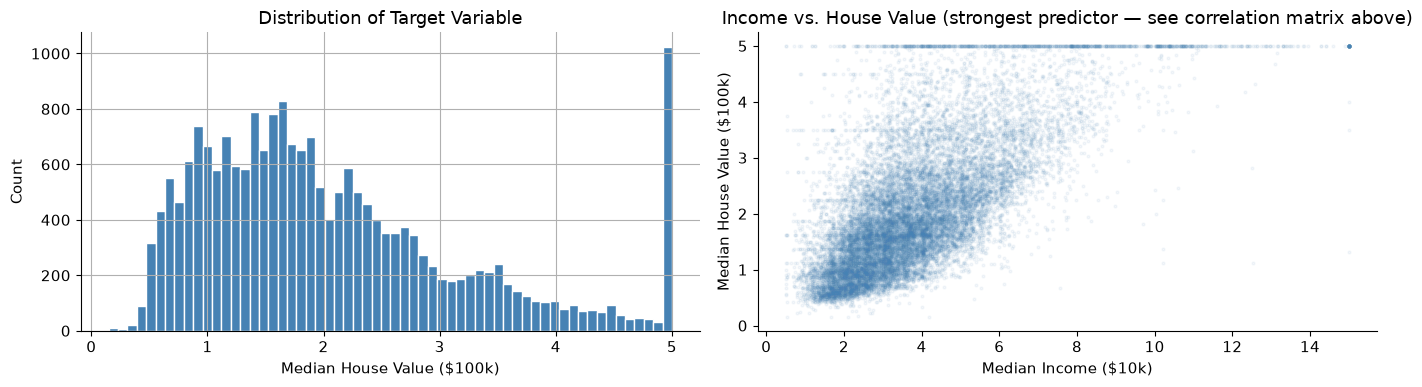

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

y.hist(bins=60, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')

axes[1].scatter(df['MedInc'], y, alpha=0.06, s=4, color=COLORS[0])
axes[1].set_xlabel('Median Income ($10k)')
axes[1].set_ylabel('Median House Value ($100k)')
axes[1].set_title('Income vs. House Value (strongest predictor — see correlation matrix above)')

plt.tight_layout()
plt.savefig('assets/california_eda.png', dpi=120, bbox_inches='tight')
plt.show()



### The $500k Ceiling: Censored Data

The histogram above shows a visible spike at $500k (5.0 in $100k units). This is **not** a market phenomenon — it is a **data collection artifact**. In the 1990 census, median house values above $500k were all recorded as exactly $500k. Statistically, these are **right-censored observations**: we know the true value is ≥ $500k, but not by how much.

Training a regression model on censored targets creates systematic bias: the model is penalized for every block whose true value exceeds $500k, yet it has no signal to learn the correct magnitude. The result is a distorted loss landscape near the ceiling.

**Decision**: We filter out the ~965 censored rows (≈ 4.7% of data) and restrict the model to the $15k–$500k range. This is a **data-scope decision**, not data cleaning — the removed rows are not wrong, just incomplete.

In [8]:
n_total  = len(df)
n_capped = (df['MedHouseVal'] >= 5.0).sum()
print(f"Censored rows (MedHouseVal == $500k): {n_capped} / {n_total} ({n_capped / n_total:.1%})")

df = df[df['MedHouseVal'] < 5.0].copy()
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f"Dataset after filtering: {len(df):,} rows")
print(f"Target range now: ${y.min() * 100_000:,.0f} – ${y.max() * 100_000:,.0f}")

Censored rows (MedHouseVal == $500k): 992 / 20640 (4.8%)
Dataset after filtering: 19,648 rows
Target range now: $14,999 – $499,100


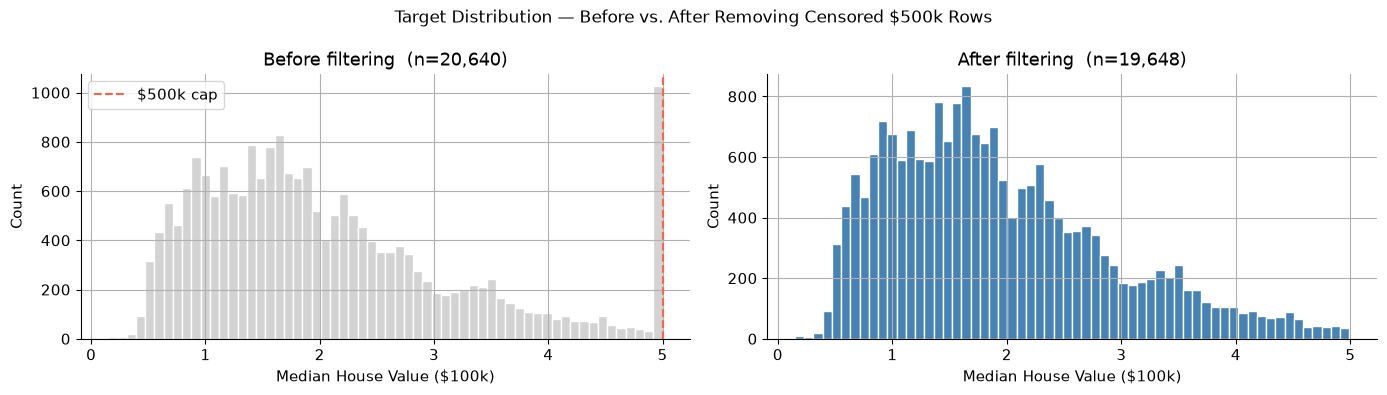

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

housing.frame['MedHouseVal'].hist(bins=60, ax=axes[0], color='lightgray', edgecolor='white')
axes[0].axvline(5.0, color=COLORS[1], linestyle='--', lw=1.5, label='$500k cap')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Before filtering  (n=20,640)')
axes[0].legend()

y.hist(bins=60, ax=axes[1], color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Median House Value ($100k)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'After filtering  (n={len(df):,})')

plt.suptitle('Target Distribution — Before vs. After Removing Censored $500k Rows', fontsize=12)
plt.tight_layout()
plt.savefig('assets/target_distribution_filtered.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='skewness'></a>
### 3.1.1 Feature Skewness and Log Transforms

Raw features are rarely on a nice, symmetric scale — and that matters for linear models:

1. **Outliers dominate OLS.** Squared-error loss amplifies extreme values. `AveOccup` has a maximum of 1243 vs. a median of ~2.8 — a single such block can pull the fit away from the rest of the data.
2. **Log-linear relationships.** If house value grows *proportionally* with income (rather than additively), the true relationship is linear in *log(income)*. A model fit on raw income will struggle to capture this curve.

`log1p(x) = log(1 + x)` compresses right tails and safely handles zero values.

**Rule of thumb**: |skewness| > 1 → consider a log transform.

Feature skewness (sorted):
AveOccup      95.41
AveBedrms     29.74
AveRooms      16.61
Population     4.96
MedInc         0.91
Latitude       0.46
HouseAge       0.07
Longitude     -0.29

Features to log-transform (|skew| > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Features to passthrough                : ['HouseAge', 'Latitude', 'Longitude']


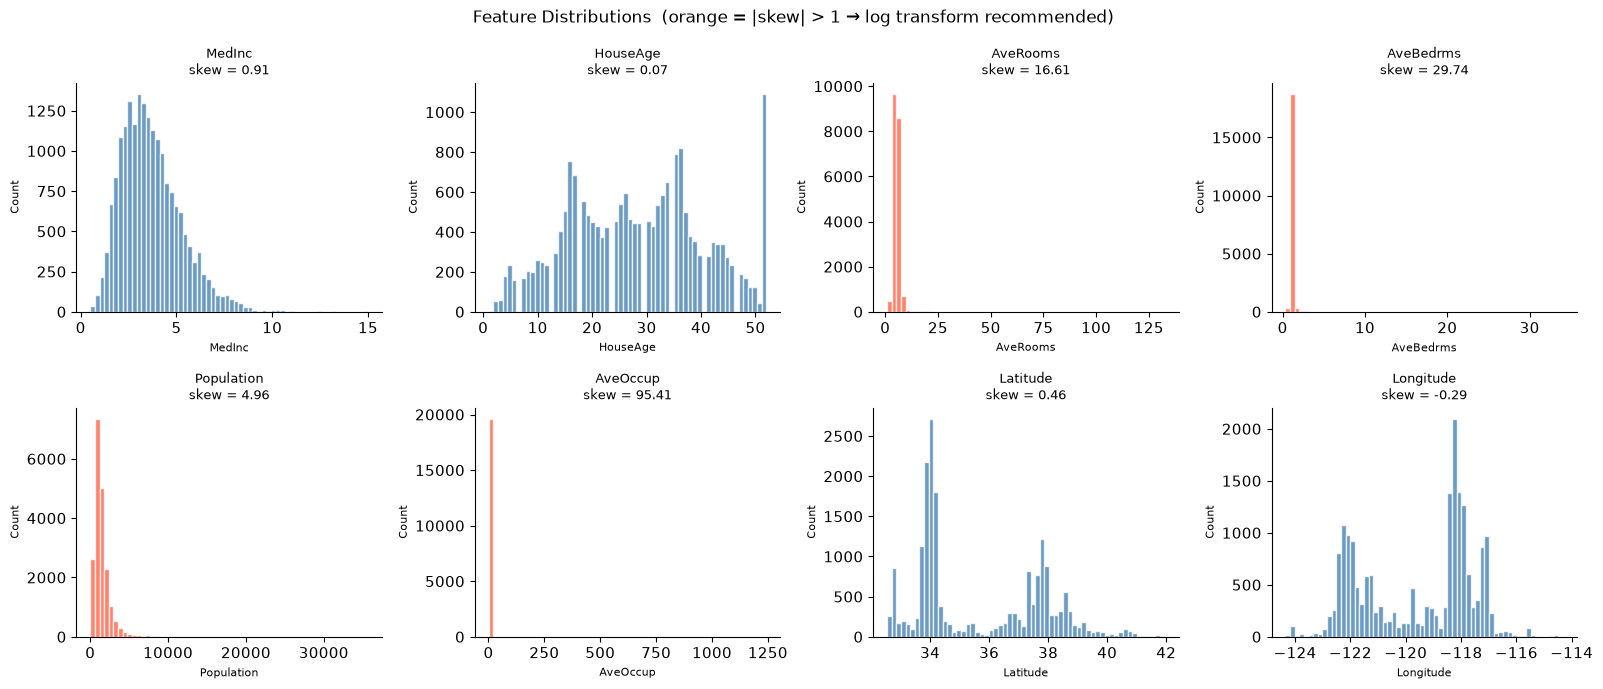

In [10]:
LOG_FEATURES  = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
PASS_FEATURES = [c for c in X.columns if c not in LOG_FEATURES]

# Compute skewness for all features
feature_skewness = X.skew().sort_values(ascending=False)
print('Feature skewness (sorted):')
print(feature_skewness.round(2).to_string())
print()
print('Features to log-transform (|skew| > 1):', LOG_FEATURES)
print('Features to passthrough                :', PASS_FEATURES)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    skew_val = X[col].skew()
    color = COLORS[1] if abs(skew_val) > 1 else COLORS[0]
    axes[i].hist(X[col], bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\nskew = {skew_val:.2f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

plt.suptitle('Feature Distributions  (orange = |skew| > 1 → log transform recommended)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

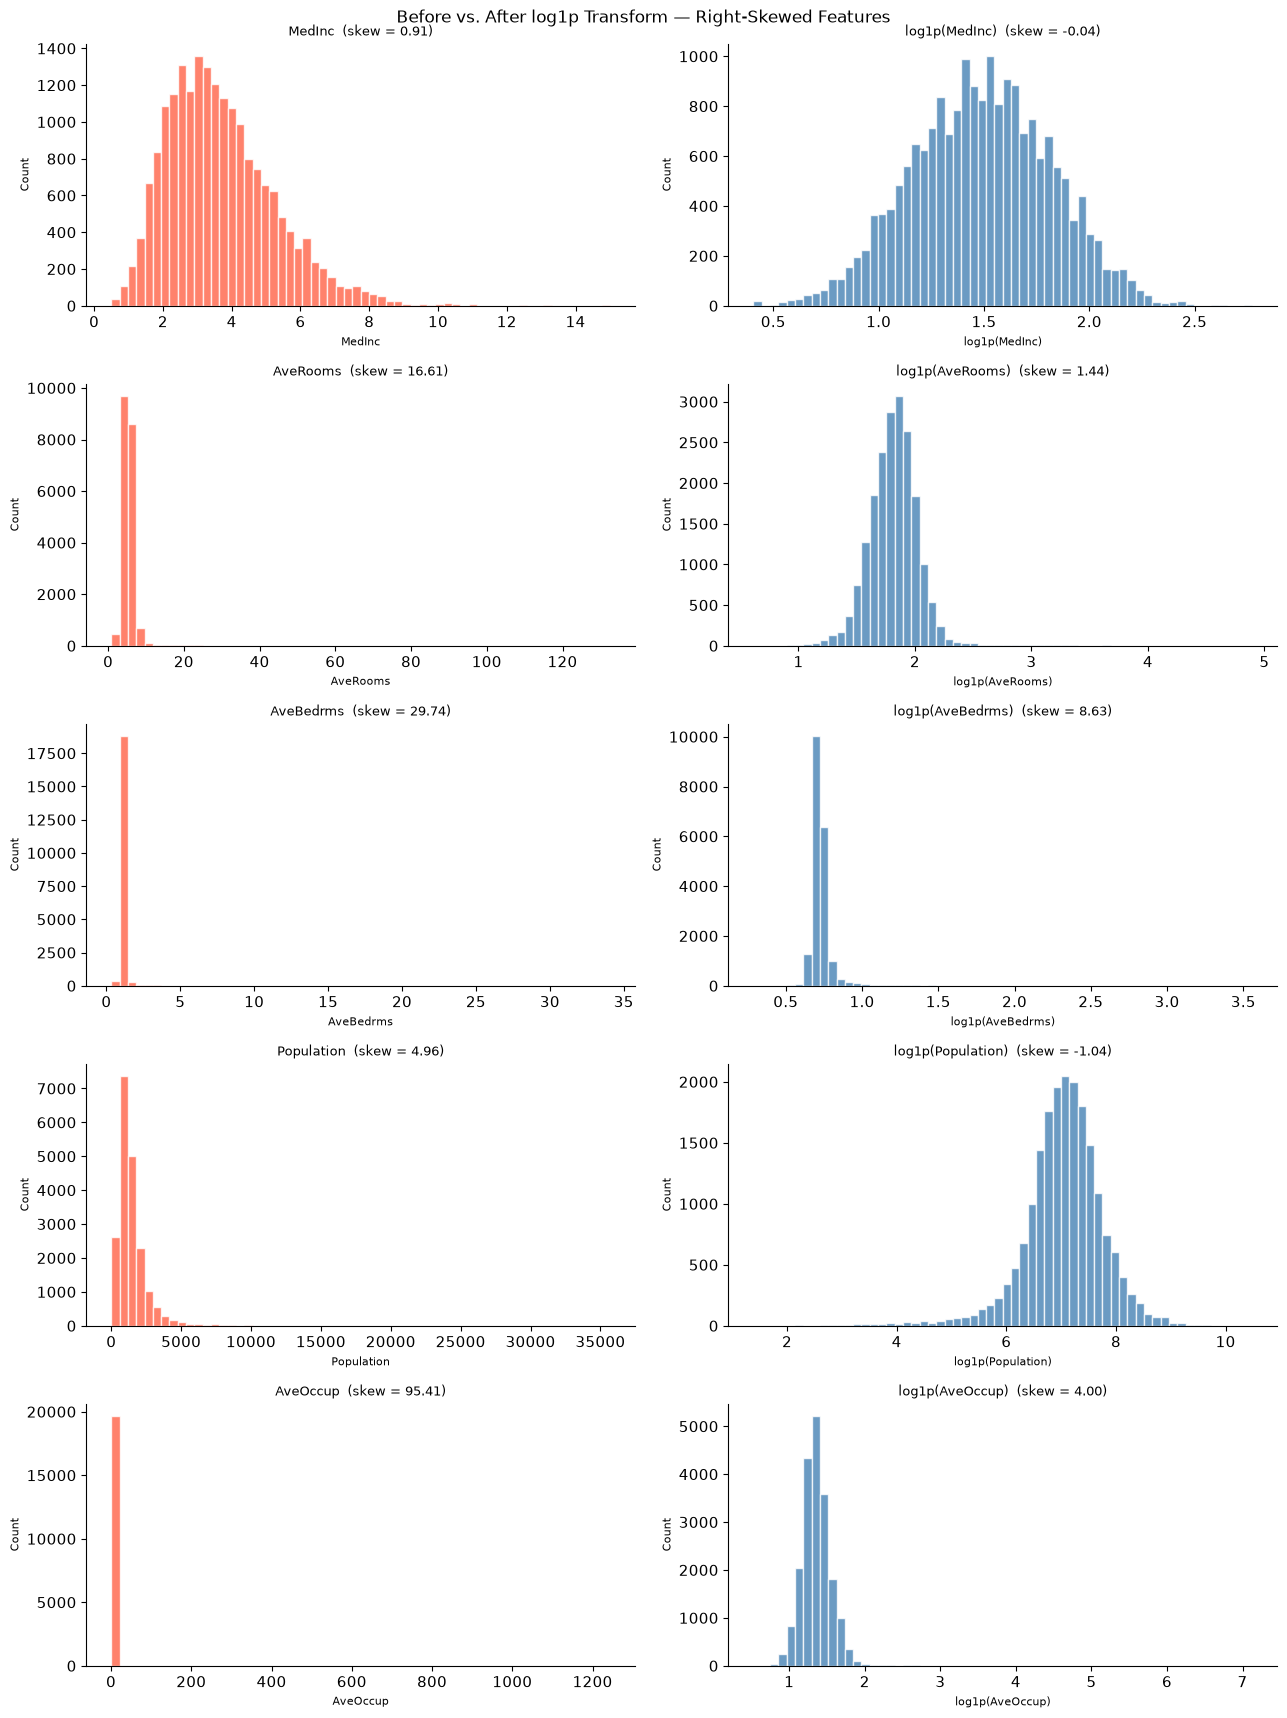

In [11]:
fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(13, 3.5 * len(LOG_FEATURES)))

for i, col in enumerate(LOG_FEATURES):
    axes[i, 0].hist(X[col], bins=60, color=COLORS[1], edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col}  (skew = {X[col].skew():.2f})', fontsize=9)
    axes[i, 0].set_xlabel(col, fontsize=8)
    axes[i, 0].set_ylabel('Count', fontsize=8)

    log_col = np.log1p(X[col])
    axes[i, 1].hist(log_col, bins=60, color=COLORS[0], edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'log1p({col})  (skew = {log_col.skew():.2f})', fontsize=9)
    axes[i, 1].set_xlabel(f'log1p({col})', fontsize=8)
    axes[i, 1].set_ylabel('Count', fontsize=8)

plt.suptitle('Before vs. After log1p Transform — Right-Skewed Features', fontsize=12)
plt.tight_layout()
plt.savefig('assets/log_transforms.png', dpi=120, bbox_inches='tight')
plt.show()


**Remarks**
* All five features become near-symmetric after log1p.
* The ColumnTransformer in Section 3.3 applies this automatically inside the pipeline.

<a id='pipelines'></a>
### 3.2 Why Pipelines? Preventing Data Leakage

A common mistake is to fit the scaler (or any preprocessing step) on the **entire** dataset before splitting into train and test — or before cross-validation folds are formed. This is **data leakage**: the scaler learns the mean and standard deviation of the held-out samples, giving an overly optimistic evaluation.

```
# ❌ WRONG — scaler sees test data
scaler.fit(X_all)          # BUG: uses test statistics
X_scaled = scaler.transform(X_all)
X_train, X_test = train_test_split(X_scaled, ...)

# ✅ RIGHT — Pipeline re-fits the scaler inside each CV fold
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
cross_val_score(pipe, X_train, y_train, cv=5)
```

With a `Pipeline`, every call to `cross_val_score` or `GridSearchCV` will:
1. Split data into train/validation folds.
2. Call `fit_transform` on the training fold (scaler learns from train only).
3. Call `transform` on the validation fold (applies the train statistics).

This guarantees a valid estimate of generalization performance.


In [12]:
# Train / test split — done once, before any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test : {X_test.shape[0]:,} samples')

# Quick baseline with a minimal pipeline (no poly features)
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])
baseline_cv = -cross_val_score(
    baseline_pipe, X_train, y_train,
    cv=CV_FOLDS, scoring='neg_mean_squared_error', n_jobs=-1
)
baseline_rmse = np.sqrt(baseline_cv.mean())
print(f'\nBaseline CV RMSE (Ridge, no poly): {baseline_rmse:.4f} ($100k)')


Train: 15,718 samples
Test : 3,930 samples

Baseline CV RMSE (Ridge, no poly): 0.6353 ($100k)


<a id='build'></a>
### 3.3 Building the Ridge Pipeline

The income–value scatter (Section 3.1) shows a non-linear curve. We address this at two levels:

**Step 1 — Log transforms (ColumnTransformer).**  
As shown in Section 3.1.1, five features (`MedInc`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`) are strongly right-skewed. We apply `log1p(x) = log(1 + x)` to each. `HouseAge`, `Latitude`, and `Longitude` pass through unchanged — they are either roughly symmetric or represent coordinates without a meaningful log scale.

**Step 2 — Polynomial interaction features.**  
We use `interaction_only=True`, which adds only **pairwise products** (e.g. `log(MedInc)×Latitude`, capturing income–location pricing effects) and drops squared terms. This gives 8 original + C(8,2) = 28 interaction terms = **36 features**.

**Step 3 — StandardScaler.** Zero-mean, unit-variance scaling is required before Ridge, which penalises coefficient magnitude and is sensitive to feature scale.

**Step 4 — Ridge regression.** L2 penalty `α·‖w‖²` stabilises the fit against the many correlated interaction features.

Our full pipeline:

```
raw features  →  ColumnTransformer   →  PolynomialFeatures  →  StandardScaler  →  Ridge
(8 features)      log1p(5 features)      (interaction_only:    (zero mean,        (L2-regularized
                  passthrough(3 feat.)    8 + 28 = 36 feat.)    unit variance)      linear model)
```

**Why Ridge?** Polynomial expansion creates many correlated features. OLS is then numerically unstable and overfits. Ridge's L2 penalty shrinks weights toward zero, reducing variance at the cost of a small bias.

In [13]:
log_preprocessor = ColumnTransformer([
    ('log',  FunctionTransformer(np.log1p, feature_names_out='one-to-one'), LOG_FEATURES),
    ('pass', 'passthrough', PASS_FEATURES),
], verbose_feature_names_out=False)

pipeline = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly',   PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge()),
])

print('Log-transform features :', LOG_FEATURES)
print('Passthrough features   :', PASS_FEATURES)

n_poly_features = (
    PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)
    .fit_transform(X_train)
    .shape[1]
)
print(f'\nDegree-{POLY_DEGREE} polynomial expansion: {X_train.shape[1]} → {n_poly_features} features')

Log-transform features : ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Passthrough features   : ['HouseAge', 'Latitude', 'Longitude']

Degree-3 polynomial expansion: 8 → 164 features


<a id='gridsearch'></a>
### 3.4 Hyperparameter Tuning with GridSearchCV

The regularization strength **α** (called `ridge__alpha` in the pipeline) controls the bias–variance tradeoff:

- **Small α → low regularization**: the model fits training data tightly, potentially overfitting.  
- **Large α → strong regularization**: weights are shrunk toward zero, potentially underfitting.  
- **Sweet spot**: the α that minimises validation error.

`GridSearchCV` evaluates every candidate α using k-fold cross-validation and returns the one with the best mean validation score. The double underscore syntax `'ridge__alpha'` refers to the `alpha` parameter of the `ridge` step inside the pipeline.


In [14]:
param_grid = {'ridge__alpha': ALPHAS}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=1,
    verbose=6,
)

print(f'Fitting {CV_FOLDS}-fold CV over {len(ALPHAS)} alpha values ...')
grid_search.fit(X_train, y_train)
print('Done.')
print(f'\nBest alpha : {grid_search.best_params_["ridge__alpha"]:.4f}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}  (improvement over baseline: '
      f'{baseline_rmse - np.sqrt(-grid_search.best_score_):.4f})')


Fitting 5-fold CV over 30 alpha values ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.361) total time=   0.1s
[CV 2/5] END ridge__alpha=0.0001;, score=(train=-0.258, test=-0.325) total time=   0.0s
[CV 3/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.313) total time=   0.0s
[CV 4/5] END ridge__alpha=0.0001;, score=(train=-0.270, test=-0.285) total time=   0.0s
[CV 5/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.372) total time=   0.0s
[CV 1/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.264, test=-0.345) total time=   0.0s
[CV 2/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.259, test=-0.324) total time=   0.0s
[CV 3/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.265, test=-0.312) total time=   0.0s
[CV 4/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.270, test=-0.281) total time=   0.0s
[CV 5/5] END ridge__alpha=0.00018873918

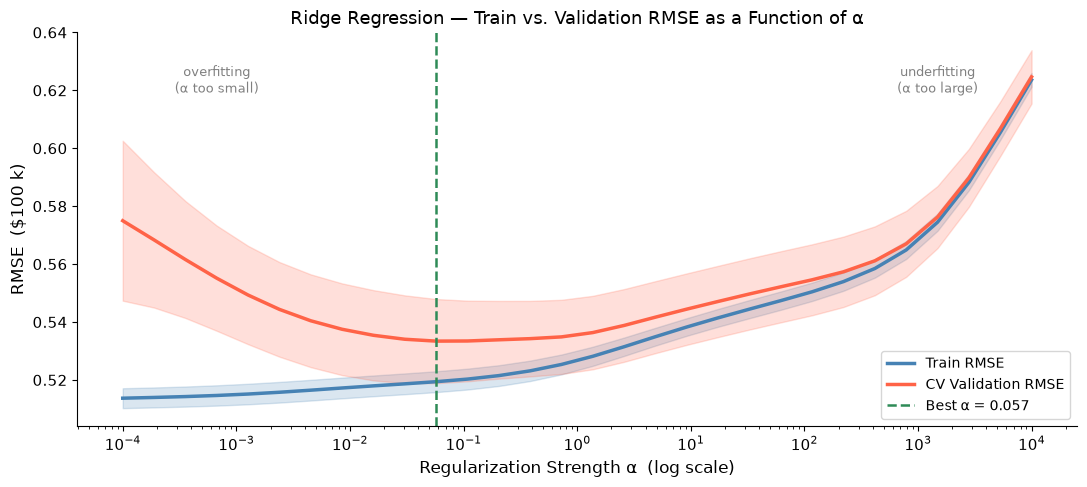

In [15]:
# ── Extract per-fold RMSE for accurate error bands ───────────────────────────
results       = pd.DataFrame(grid_search.cv_results_)
alphas_tested = results['param_ridge__alpha'].astype(float).values

fold_train_rmse = np.array([
    np.sqrt(-results[f'split{k}_train_score'].values)
    for k in range(CV_FOLDS)
])  # shape (CV_FOLDS, n_alphas)

fold_val_rmse = np.array([
    np.sqrt(-results[f'split{k}_test_score'].values)
    for k in range(CV_FOLDS)
])

train_rmse     = fold_train_rmse.mean(axis=0)
train_rmse_std = fold_train_rmse.std(axis=0)
cv_rmse        = fold_val_rmse.mean(axis=0)
cv_rmse_std    = fold_val_rmse.std(axis=0)

best_alpha = grid_search.best_params_['ridge__alpha']

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogx(alphas_tested, train_rmse, color=COLORS[0], lw=2.5, label='Train RMSE')
ax.fill_between(alphas_tested,
                train_rmse - train_rmse_std, train_rmse + train_rmse_std,
                alpha=0.2, color=COLORS[0])

ax.semilogx(alphas_tested, cv_rmse, color=COLORS[1], lw=2.5, label='CV Validation RMSE')
ax.fill_between(alphas_tested,
                cv_rmse - cv_rmse_std, cv_rmse + cv_rmse_std,
                alpha=0.2, color=COLORS[1])

ax.axvline(best_alpha, color=COLORS[2], linestyle='--', lw=1.8,
           label=f'Best α = {best_alpha:.3f}')

# Annotate regions
ylo, yhi = ax.get_ylim()
ytext = ylo + (yhi - ylo) * 0.92
ax.text(alphas_tested[3],  ytext, 'overfitting\n(α too small)',
        ha='center', va='top', fontsize=9, color='gray')
ax.text(alphas_tested[-4], ytext, 'underfitting\n(α too large)',
        ha='center', va='top', fontsize=9, color='gray')

ax.set_xlabel('Regularization Strength α  (log scale)', fontsize=12)
ax.set_ylabel('RMSE  ($100 k)', fontsize=12)
ax.set_title('Ridge Regression — Train vs. Validation RMSE as a Function of α', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('assets/ridge_validation_curve.png', dpi=130, bbox_inches='tight')
plt.show()

**Interpretation:**
* Left (small α): train RMSE low, CV RMSE high → overfitting
* Right (large α): both RMSEs high → underfitting
* Minimum of CV RMSE curve = best regularization strength

<a id='eval1'></a>
### 3.5 Model Evaluation on the Test Set


Test RMSE (Ridge, degree-3): 0.5391  ($100k)
In dollar terms: ± $53,906


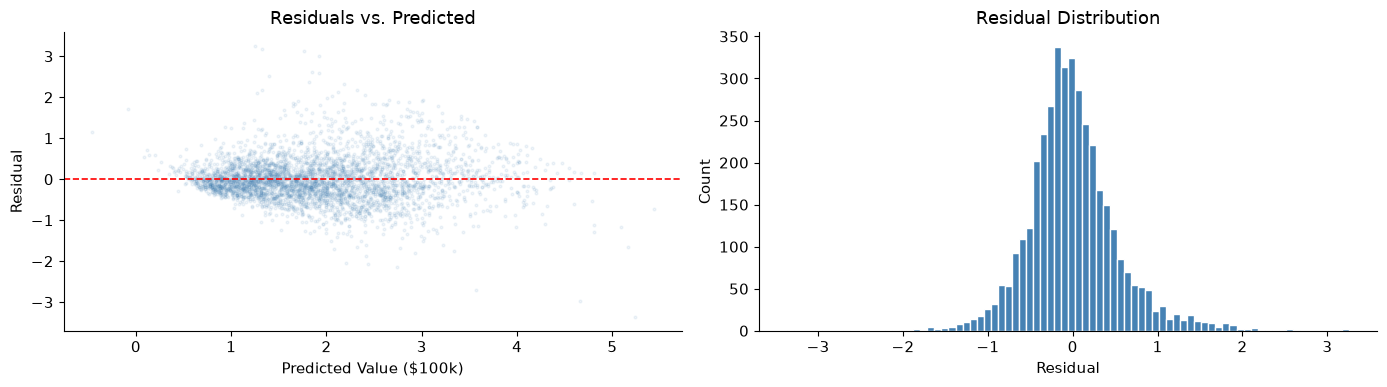

In [16]:
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE (Ridge, degree-{POLY_DEGREE}): {test_rmse:.4f}  ($100k)')
print(f'In dollar terms: ± ${test_rmse * 100_000:,.0f}')

# Residual plot
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred, residuals, alpha=0.08, s=4, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Value ($100k)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted')

axes[1].hist(residuals, bins=80, color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('assets/ridge_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


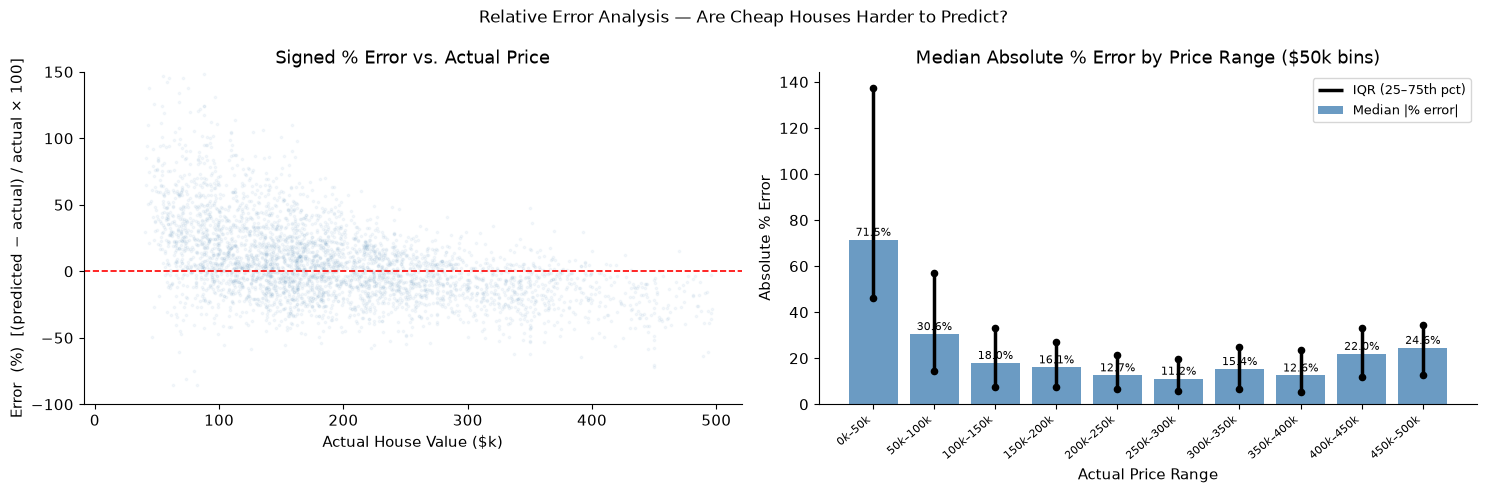

MAPE (mean absolute % error): 24.5%
Median absolute % error     : 17.1%


In [17]:
bin_width_k = 50  # bin width in $k — try 25, 50, 100 to see coarser/finer breakdowns

pct_error = (y_pred - y_test) / y_test * 100          # signed: + = over-predicted
abs_pct_error = np.abs(pct_error)

price_dollars = y_test * 100_000
bin_width = bin_width_k * 1_000
max_price = int(np.ceil(price_dollars.max() / bin_width) * bin_width) + bin_width
bins = np.arange(0, max_price, bin_width)
labels = [f'${int(b/1000)}k–${int((b+bin_width)/1000)}k' for b in bins[:-1]]
price_bin = pd.cut(price_dollars, bins=bins, labels=labels)

bin_stats = pd.DataFrame({
    'abs_pct_error': abs_pct_error,
    'pct_error': pct_error,
    'price_bin': price_bin,
}).groupby('price_bin', observed=True).agg(
    median_abs_pct=('abs_pct_error', 'median'),
    p25=('abs_pct_error', lambda x: np.percentile(x, 25)),
    p75=('abs_pct_error', lambda x: np.percentile(x, 75)),
    n=('abs_pct_error', 'count'),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter of signed % error vs actual price
axes[0].scatter(price_dollars / 1000, pct_error, alpha=0.05, s=3, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].set_ylim(-100, 150)

# Right: binned median absolute % error with IQR band
x_pos = np.arange(len(bin_stats))
axes[1].bar(x_pos, bin_stats['median_abs_pct'], color=COLORS[0], alpha=0.8, label='Median |% error|')
axes[1].vlines(x_pos,
               bin_stats['p25'], bin_stats['p75'],
               color='black', lw=2.5, label='IQR (25–75th pct)')
axes[1].scatter(x_pos, bin_stats['p75'], color='black', s=20, zorder=5)
axes[1].scatter(x_pos, bin_stats['p25'], color='black', s=20, zorder=5)

for i, (idx, row) in enumerate(bin_stats.iterrows()):
    axes[1].text(i, row['median_abs_pct'] + 0.5, f"{row['median_abs_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bin_stats.index, rotation=40, ha='right', fontsize=8)
axes[1].set_xlabel('Actual Price Range')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error by Price Range (${bin_width_k}k bins)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Are Cheap Houses Harder to Predict?', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_by_price.png', dpi=130, bbox_inches='tight')
plt.show()

mape = abs_pct_error.mean()
print(f'MAPE (mean absolute % error): {mape:.1f}%')
print(f'Median absolute % error     : {abs_pct_error.median():.1f}%')

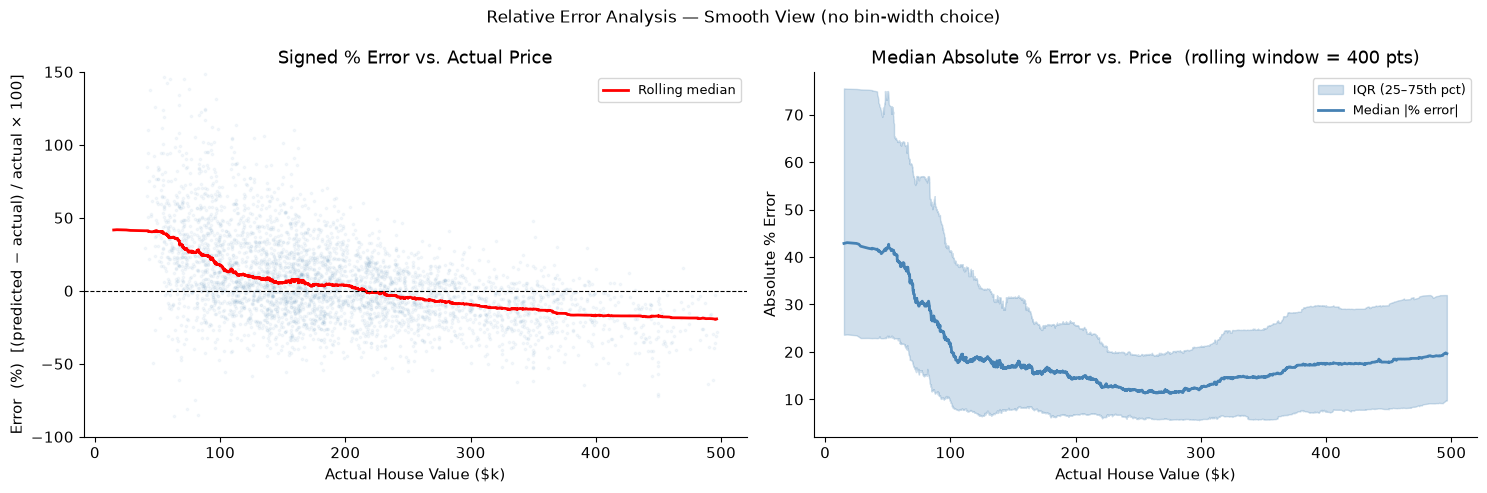

In [18]:
SMOOTH_WINDOW = 400  # number of nearest neighbors (by price) used for rolling quantiles

# Sort test points by actual price so the rolling window is price-ordered
sort_idx = np.argsort(price_dollars.values)
price_s  = price_dollars.values[sort_idx] / 1_000   # in $k
pct_s    = pct_error.values[sort_idx]
abs_s    = abs_pct_error.values[sort_idx]

kw = dict(window=SMOOTH_WINDOW, center=True, min_periods=50)
med_signed = pd.Series(pct_s).rolling(**kw).median()
med_abs    = pd.Series(abs_s).rolling(**kw).median()
p25        = pd.Series(abs_s).rolling(**kw).quantile(0.25)
p75        = pd.Series(abs_s).rolling(**kw).quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter + rolling median of signed % error
axes[0].scatter(price_s, pct_s, alpha=0.05, s=3, color=COLORS[0])
axes[0].plot(price_s, med_signed, color='red', lw=2, label='Rolling median')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_ylim(-100, 150)
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].legend(fontsize=9)

# Right: rolling median absolute % error + IQR band
axes[1].fill_between(price_s, p25, p75, alpha=0.25, color=COLORS[0], label='IQR (25–75th pct)')
axes[1].plot(price_s, med_abs, color=COLORS[0], lw=2, label='Median |% error|')
axes[1].set_xlabel('Actual House Value ($k)')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error vs. Price  (rolling window = {SMOOTH_WINDOW} pts)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Smooth View (no bin-width choice)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_smooth.png', dpi=130, bbox_inches='tight')
plt.show()

The smooth curve above shows the same signal as the bar chart, but without a bin-width choice. Both views are complementary: the bars give precise per-range numbers; the smooth curve makes the overall trend and local anomalies (the \$300k bump, the rise above \$400k) easier to read at a glance.

---

**What does this plot tell us?**

The right panel reveals a clear pattern: a **steep monotonic decline** from the cheapest houses down to a sweet spot around \$250k–\$300k, followed by a gradual rise at the expensive end.

**Very cheap houses (\$0–\$50k) — 71.5% median error, IQR reaching ~140%**

This is an extreme segment. Almost no California census blocks reported a median value below \$50k in 1990, so the model has barely any training signal here. The enormous IQR (the whisker reaches ~140%) tells us predictions are nearly random — the few data points are so heterogeneous that even their central tendency is uncertain.

**The monotonic decline (\$50k → \$250k) — 30.5% → 11.8%**

Error falls steadily as house value increases. Two effects drive this:

1. *Data density.* The training distribution is centered around \$150k–\$300k. As we move right across this range, the model sees progressively more examples and fits better.
2. *Percentage amplification.* A fixed absolute dollar error of, say, \$15k is 30% of a \$50k house but only 6% of a \$250k house. Even if prediction quality were identical across the range, the relative error metric would still show this downward slope.

**Sweet spot (\$250k–\$300k) — 11.8% median error**

This is where the model performs best: the highest concentration of training data, the most consistent income-location-price relationships, and the lowest percentage amplification effect. Absolute dollar errors in this bin are likely similar to neighboring bins — the relative metric just favors this range.

**The slight bump at \$300k–\$350k (15.4%) then recovery at \$350k–\$400k (12.5%)**

This small anomaly is worth noting. One plausible explanation is a feature interaction: blocks in the \$300k–\$350k range may straddle a geographic boundary (e.g., the edge of a high-demand coastal county vs. an inland suburb) where the model's polynomial features produce a local misfit. With only 8 census variables, the model cannot distinguish otherwise-similar blocks that sit on opposite sides of a neighborhood boundary.

**Expensive houses (\$400k–\$500k) — rising to 22–24.5%**

Error climbs again at the high end for structural reasons:

1. *Proximity to the censoring boundary.* We removed the hard-capped \$500k rows, but blocks just below that cap may still carry artifacts of the censoring process — their features can be systematically unusual relative to blocks priced well below the ceiling.
2. *Luxury non-linearities.* High-end prices reflect factors the 8 census features cannot capture: school district prestige, architectural quality, micro-neighborhood cachet. The model undershoots these values.
3. *Sparse data.* Like the cheap end, few training examples exist here, so the model cannot specialize.

**Left panel — signed errors**

The scatter confirms the directional story: cheap houses are overwhelmingly **over-predicted** (positive signed error, large upward spread), while expensive houses cluster just below the zero line, reflecting systematic **under-prediction**. This is the classic **regression-to-the-mean** bias — a linear model trained on an asymmetric distribution anchors predictions toward the bulk of the data, dragging cheap predictions up and expensive predictions down.

**Takeaway**: relative (percentage) error is a more honest evaluation metric than RMSE for datasets with wide price ranges. RMSE would mask the poor performance at the extremes because those segments are numerically small and infrequent.

---
<a id='ex11'></a>
### Exercise 1.1 — Effect of Polynomial Degree (Basic)

The current walkthrough uses `POLY_DEGREE = 3`. In this exercise you will compare degree 1, 2, and 3 to see how polynomial degree interacts with regularization.

**Tasks:**
1. For each degree in `[1, 2, 3]`, build a Ridge pipeline, run `GridSearchCV` with the same `ALPHAS`, and record the best CV RMSE and the corresponding best α.
2. Print a summary table.
3. Answer: does a higher polynomial degree always improve test performance? Why or why not?


In [ ]:
from sklearn.base import clone

# Keep the same training data, preprocessing, alpha candidates, and CV folds.
# Reuse the fitted search from Section 3.4 for its polynomial degree.
previous_degree = grid_search.best_estimator_.named_steps['poly'].degree
degree_searches = {}
degree_results = []

for degree in [1, 2, 3]:
    if degree == previous_degree:
        degree_search = grid_search
        print(f'Degree {degree}: reusing the search from Section 3.4.')
    else:
        # clone creates an unfitted copy; only the polynomial degree changes.
        degree_pipeline = clone(grid_search.estimator).set_params(
            poly__degree=degree
        )
        degree_search = GridSearchCV(
            degree_pipeline,
            param_grid={'ridge__alpha': ALPHAS},
            cv=CV_FOLDS,
            scoring='neg_mean_squared_error',
            return_train_score=True,
            n_jobs=1,
        )
        print(f'Degree {degree}: fitting {len(ALPHAS)} alphas × {CV_FOLDS} folds ...')
        degree_search.fit(X_train, y_train)

    # Save each search for later inspection without replacing grid_search.
    degree_searches[degree] = degree_search
    degree_results.append({
        'Degree': degree,
        'Features': degree_search.best_estimator_.named_steps['poly'].n_output_features_,
        'Best alpha': degree_search.best_params_['ridge__alpha'],
        # Same CV RMSE definition as Section 3.4: sqrt(mean CV MSE).
        'CV RMSE ($100k)': np.sqrt(-degree_search.best_score_),
    })

degree_summary = pd.DataFrame(degree_results).sort_values('Degree')
print()
print(degree_summary.to_string(
    index=False,
    formatters={
        'Best alpha': '{:.4f}'.format,
        'CV RMSE ($100k)': '{:.4f}'.format,
    },
))


Degree 1: fitting 30 alphas × 5 folds ...
Degree 2: fitting 30 alphas × 5 folds ...
Degree 3: reusing the search from Section 3.4.

 Degree  Features Best alpha CV RMSE ($100k)
      1         8     2.5929          0.6183
      2        44     0.0024          0.5452
      3       164     0.0574          0.5336


In [ ]:
# Evaluate the already-fitted best model for each degree on the same test set.
# Alpha was selected by cross-validation; no fitting is performed here.
degree_test_predictions = {}
degree_test_rmse = {}

for degree in [1, 2, 3]:
    degree_model = degree_searches[degree].best_estimator_
    degree_test_predictions[degree] = degree_model.predict(X_test)
    degree_test_rmse[degree] = np.sqrt(
        mean_squared_error(y_test, degree_test_predictions[degree])
    )

degree_comparison = degree_summary.copy()
degree_comparison['Test RMSE ($100k)'] = degree_comparison['Degree'].map(degree_test_rmse)
degree_comparison['Test RMSE ($)'] = degree_comparison['Test RMSE ($100k)'] * 100_000

print(degree_comparison.to_string(
    index=False,
    formatters={
        'Best alpha': '{:.4f}'.format,
        'CV RMSE ($100k)': '{:.4f}'.format,
        'Test RMSE ($100k)': '{:.4f}'.format,
        'Test RMSE ($)': '${:,.0f}'.format,
    },
))


 Degree  Features Best alpha CV RMSE ($100k) Test RMSE ($100k) Test RMSE ($)
      1         8     2.5929          0.6183            0.6285       $62,854
      2        44     0.0024          0.5452            0.5513       $55,125
      3       164     0.0574          0.5336            0.5391       $53,906


Does a higher polynomial degree always improve test performance? Why or why not?

No, un mayor grado polinómico no siempre mejora el desempeño en test. Aunque permite representar relaciones más complejas, también puede ajustar ruido del entrenamiento y producir sobreajuste.

En este experimento, aumentar el grado de 1 a 2 y a 3 redujo el test RMSE de 0.6285 a 0.5513 y 0.5391, respectivamente. Por tanto, sí mejoró el desempeño global en test según esta métrica. Sin embargo, esto no garantiza una mejora en todas las observaciones o rangos de precio, porque el RMSE resume el conjunto completo.

Además, la mejora del grado 3 frente al 2 fue aproximadamente del 2.2 %, mientras que las características aumentaron de 44 a 164. Por ello, al elegir el grado conviene considerar tanto la precisión como el costo computacional.

---
<a id='ex12'></a>
### Exercise 1.2 — Ridge vs. Lasso

**Ridge** (L2) shrinks all coefficients toward zero but rarely to exactly zero.  
**Lasso** (L1) tends to produce **sparse** models — many coefficients become exactly zero, effectively performing feature selection.

**Tasks:**
1. Build a Lasso pipeline (same structure: `PolynomialFeatures → StandardScaler → Lasso`) and tune `lasso__alpha` with `GridSearchCV`.
2. Compare test RMSE for Ridge and Lasso.
3. Count how many of the degree-3 polynomial coefficients are exactly zero for each model. What does this tell you about feature selection?
4. Plot the top-20 non-zero Lasso coefficients.


In [ ]:
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning

# Same log transforms, degree 3, scaling, training split, and CV folds as Ridge.
lasso_pipeline = Pipeline([
    ('log_transform', clone(log_preprocessor)),
    ('poly', PolynomialFeatures(
        degree=3, include_bias=False, interaction_only=False
    )),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(
        max_iter=200_000,
        tol=1e-4,
        precompute=True,
        selection='random',
        random_state=RANDOM_STATE,
    )),
])

# Tune Lasso separately: equal alpha values do not mean equal L1/L2 penalties.
lasso_grid_search = GridSearchCV(
    lasso_pipeline,
    param_grid={'lasso__alpha': ALPHAS},
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=1,
    error_score='raise',
    verbose=1,
)

# The setup hides warnings; do not silently accept an unconverged Lasso fit.
with warnings.catch_warnings():
    warnings.simplefilter('error', ConvergenceWarning)
    lasso_grid_search.fit(X_train, y_train)

# Keep a fitted copy so future comparisons can reload it without training.
from joblib import dump
dump(lasso_grid_search, 'assets/lasso_degree3_search.joblib')

best_lasso_model = lasso_grid_search.best_estimator_
lasso_test_pred = best_lasso_model.predict(X_test)
lasso_cv_rmse = np.sqrt(-lasso_grid_search.best_score_)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print(f'Best Lasso alpha: {lasso_grid_search.best_params_["lasso__alpha"]:.6g}')
print(f'Lasso CV RMSE:    {lasso_cv_rmse:.4f} ($100k)')
print(f'Lasso test RMSE:  {lasso_test_rmse:.4f} ($100k)')
print(f'Final fit iterations: {best_lasso_model.named_steps["lasso"].n_iter_:,}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Lasso alpha: 0.0001
Lasso CV RMSE:    0.5367 ($100k)
Lasso test RMSE:  0.5454 ($100k)
Final fit iterations: 121,240


For this comparison we use **degree 3**, matching the previously fitted Ridge model. Both models use the same log transforms, polynomial features, scaling, training/test split, and CV folds. Each model tunes its own alpha.

The **top 20 non-zero coefficients** are selected by descending absolute Lasso coefficient, while retaining their signs in the table and plot. These are coefficients of standardized, expanded features, not causal importance scores.

Lasso: 84 exactly zero; 80 non-zero; 164 total.

Top non-zero Lasso coefficients, ranked by absolute magnitude:
                                        Feature Lasso coefficient |Lasso coefficient|
                      log1p(MedInc) Longitude^2          4.493949            4.493949
                           Latitude Longitude^2         -3.675923            3.675923
                                  log1p(MedInc)         -3.201754            3.201754
               log1p(MedInc) HouseAge Longitude         -2.789442            2.789442
                                       HouseAge         -2.112099            2.112099
                           HouseAge Longitude^2          2.096671            2.096671
                         log1p(MedInc) Latitude         -1.684537            1.684537
              log1p(MedInc)^2 log1p(Population)          1.573688            1.573688
                                      Longitude         -1.488957            1.488957
                log1p(MedInc

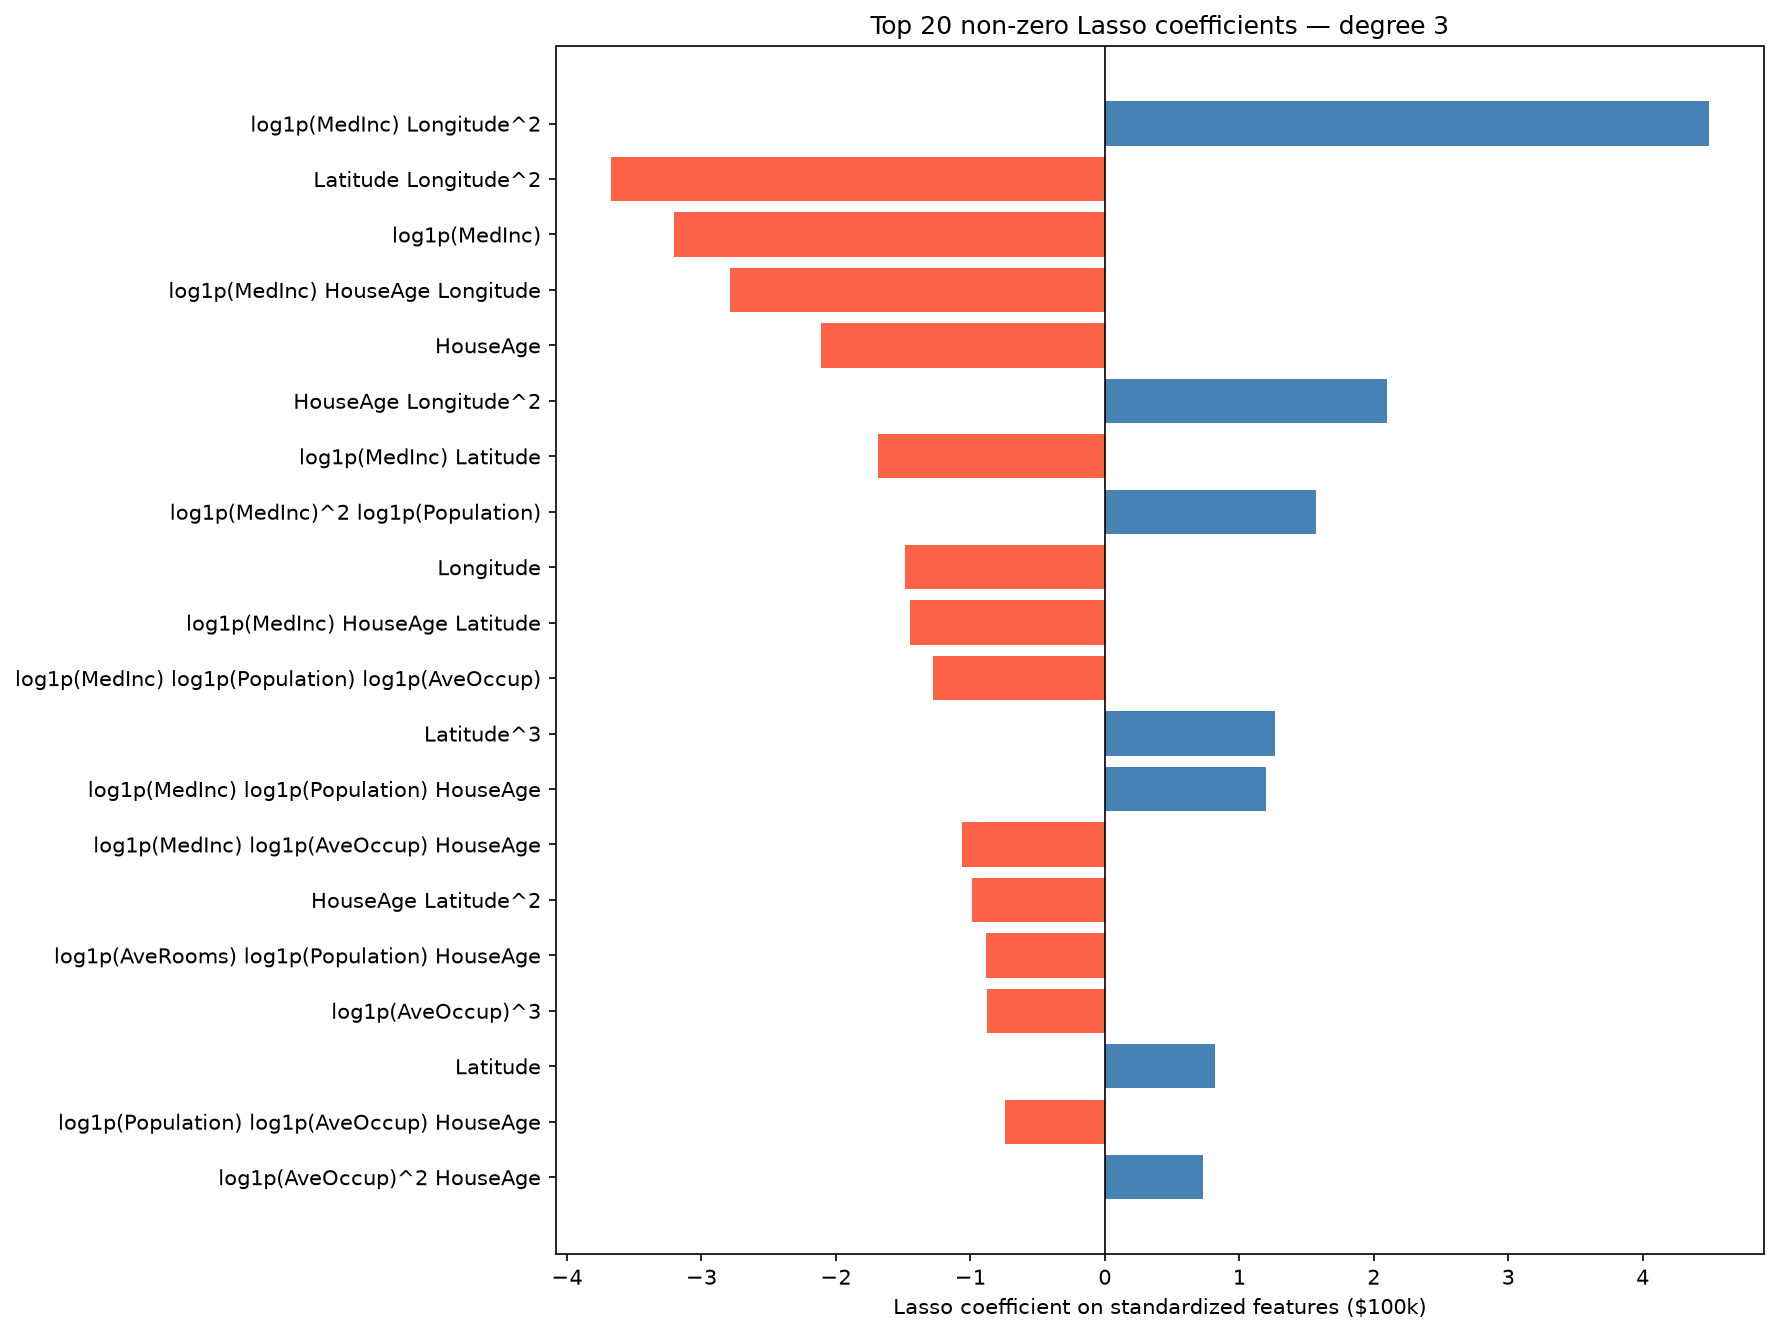

In [ ]:
# Names refer to the log-transformed features before polynomial expansion.
lasso_input_names = best_lasso_model.named_steps['log_transform'].get_feature_names_out()
lasso_display_names = np.array([
    f'log1p({name})' if name in LOG_FEATURES else name
    for name in lasso_input_names
])
lasso_feature_names = best_lasso_model.named_steps['poly'].get_feature_names_out(
    lasso_display_names
)
lasso_weights = best_lasso_model.named_steps['lasso'].coef_

lasso_coefficients = pd.DataFrame({
    'Feature': lasso_feature_names,
    'Lasso coefficient': lasso_weights,
    '|Lasso coefficient|': np.abs(lasso_weights),
}).sort_values('|Lasso coefficient|', ascending=False)

# Exactly zero, rather than merely close to zero.
lasso_zero_count = int(np.sum(lasso_weights == 0))
print(f'Lasso: {lasso_zero_count} exactly zero; '
      f'{np.count_nonzero(lasso_weights)} non-zero; {len(lasso_weights)} total.')

top20_lasso = lasso_coefficients[
    lasso_coefficients['Lasso coefficient'] != 0
].head(20)
print('\nTop non-zero Lasso coefficients, ranked by absolute magnitude:')
print(top20_lasso.to_string(
    index=False,
    formatters={
        'Lasso coefficient': '{:.6f}'.format,
        '|Lasso coefficient|': '{:.6f}'.format,
    },
))

# Keep the sign in the plot; rank by magnitude.
plot_top20 = top20_lasso.iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(
    plot_top20['Feature'], plot_top20['Lasso coefficient'],
    color=['steelblue' if value > 0 else 'tomato'
           for value in plot_top20['Lasso coefficient']],
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso coefficient on standardized features ($100k)')
ax.set_title(f'Top {len(top20_lasso)} non-zero Lasso coefficients — degree 3')
fig.tight_layout()
fig.savefig('assets/lasso_degree3_top20.png', dpi=150, bbox_inches='tight')
plt.show()


Loaded the saved Lasso model; no training was repeated.
Model  Degree Best alpha CV RMSE ($100k) Test RMSE ($100k)  Zero coefficients  Non-zero coefficients
Ridge       3  0.0573615          0.5336            0.5391                  0                    164
Lasso       3     0.0001          0.5367            0.5454                 84                     80

Ridge vs. Lasso on the top non-zero Lasso features:
                                        Feature  Lasso coefficient  |Lasso coefficient|  Ridge coefficient
                      log1p(MedInc) Longitude^2           4.493949             4.493949           3.966119
                           Latitude Longitude^2          -3.675923             3.675923          -4.745810
                                  log1p(MedInc)          -3.201754             3.201754          -3.683226
               log1p(MedInc) HouseAge Longitude          -2.789442             2.789442          -4.641379
                                       HouseAge      

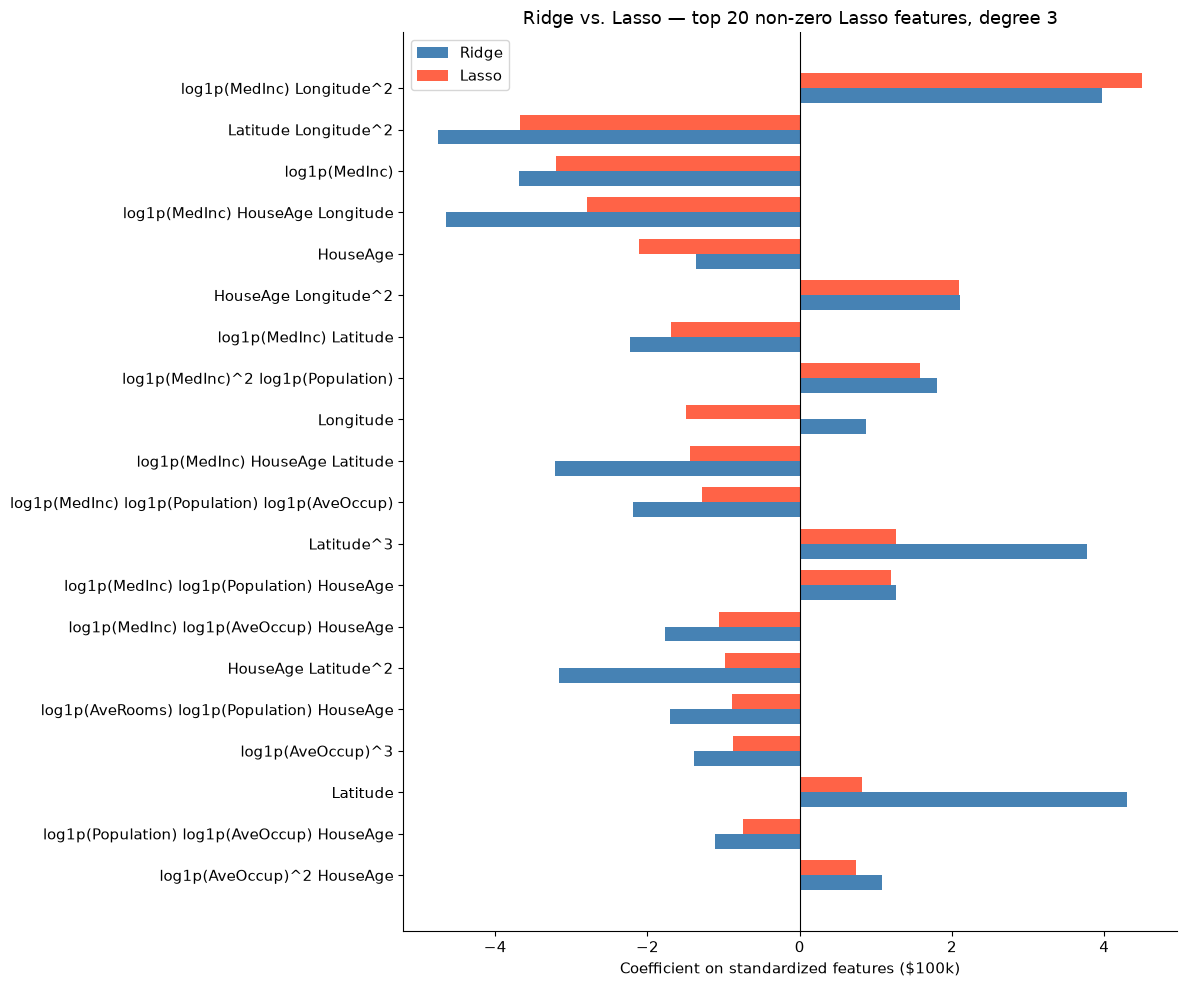

In [21]:
# Reuse the fitted Ridge search; never call fit on Ridge in this exercise.
ridge_reference_search = grid_search
ridge_reference = ridge_reference_search.best_estimator_
assert ridge_reference.named_steps['poly'].degree == 3, 'Use the degree-3 Ridge model.'

# Rebuild all Lasso comparison data here; the previous plot need not be rerun.
# A displayed notebook output does not imply its variables exist in this session.
if 'lasso_grid_search' not in globals():
    from joblib import load
    lasso_grid_search = load('assets/lasso_degree3_search.joblib')
    print('Loaded the saved Lasso model; no training was repeated.')

best_lasso_model = lasso_grid_search.best_estimator_
assert best_lasso_model.named_steps['poly'].degree == 3, 'Use the degree-3 Lasso model.'
lasso_weights = best_lasso_model.named_steps['lasso'].coef_
lasso_input_names = best_lasso_model.named_steps['log_transform'].get_feature_names_out()
lasso_display_names = np.array([
    f'log1p({name})' if name in LOG_FEATURES else name
    for name in lasso_input_names
])
lasso_feature_names = best_lasso_model.named_steps['poly'].get_feature_names_out(
    lasso_display_names
)
lasso_zero_count = int(np.sum(lasso_weights == 0))
lasso_cv_rmse = np.sqrt(-lasso_grid_search.best_score_)
lasso_test_rmse = np.sqrt(mean_squared_error(
    y_test, best_lasso_model.predict(X_test)
))

lasso_coefficients = pd.DataFrame({
    'Feature': lasso_feature_names,
    'Lasso coefficient': lasso_weights,
    '|Lasso coefficient|': np.abs(lasso_weights),
}).sort_values('|Lasso coefficient|', ascending=False)
top20_lasso = lasso_coefficients[
    lasso_coefficients['Lasso coefficient'] != 0
].head(20)

ridge_weights = ridge_reference.named_steps['ridge'].coef_
assert len(ridge_weights) == len(lasso_weights)
assert np.array_equal(
    ridge_reference.named_steps['log_transform'].get_feature_names_out(),
    lasso_input_names,
)
assert np.allclose(
    ridge_reference.named_steps['scaler'].scale_,
    best_lasso_model.named_steps['scaler'].scale_,
)

ridge_lasso_summary = pd.DataFrame([
    {
        'Model': 'Ridge', 'Degree': 3,
        'Best alpha': ridge_reference_search.best_params_['ridge__alpha'],
        'CV RMSE ($100k)': np.sqrt(-ridge_reference_search.best_score_),
        'Test RMSE ($100k)': np.sqrt(mean_squared_error(
            y_test, ridge_reference.predict(X_test)
        )),
        'Zero coefficients': int(np.sum(ridge_weights == 0)),
        'Non-zero coefficients': int(np.count_nonzero(ridge_weights)),
    },
    {
        'Model': 'Lasso', 'Degree': 3,
        'Best alpha': lasso_grid_search.best_params_['lasso__alpha'],
        'CV RMSE ($100k)': lasso_cv_rmse,
        'Test RMSE ($100k)': lasso_test_rmse,
        'Zero coefficients': lasso_zero_count,
        'Non-zero coefficients': int(np.count_nonzero(lasso_weights)),
    },
])
print(ridge_lasso_summary.to_string(
    index=False,
    formatters={
        'Best alpha': '{:.6g}'.format,
        'CV RMSE ($100k)': '{:.4f}'.format,
        'Test RMSE ($100k)': '{:.4f}'.format,
    },
))

# Compare Ridge on the SAME 20 features selected by Lasso's coefficient ranking.
ridge_coefficient_lookup = pd.Series(ridge_weights, index=lasso_feature_names)
top20_coefficient_comparison = top20_lasso.copy()
top20_coefficient_comparison['Ridge coefficient'] = (
    top20_coefficient_comparison['Feature'].map(ridge_coefficient_lookup)
)
print('\nRidge vs. Lasso on the top non-zero Lasso features:')
print(top20_coefficient_comparison.to_string(
    index=False, float_format=lambda value: f'{value:.6f}'
))

comparison_plot = top20_coefficient_comparison.iloc[::-1]
positions = np.arange(len(comparison_plot))
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(positions - 0.18, comparison_plot['Ridge coefficient'],
        height=0.36, color='steelblue', label='Ridge')
ax.barh(positions + 0.18, comparison_plot['Lasso coefficient'],
        height=0.36, color='tomato', label='Lasso')
ax.set_yticks(positions, comparison_plot['Feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient on standardized features ($100k)')
ax.set_title('Ridge vs. Lasso — top 20 non-zero Lasso features, degree 3')
ax.legend()
fig.tight_layout()
fig.savefig('assets/ridge_vs_lasso_degree3_top20.png', dpi=150, bbox_inches='tight')
plt.show()


**Reflexión del ejercicio:** Ridge y Lasso obtuvieron resultados cercanos, aunque Ridge logró un menor test RMSE: **0.5391 frente a 0.5454**. Sin embargo, Lasso dejó **84 de los 164 coeficientes exactamente en cero**, obteniendo una predicción con menos términos activos y una pérdida pequeña de precisión.

Esto muestra que Lasso puede simplificar el modelo mediante selección de características, mientras que Ridge conserva y regulariza todas sus contribuciones. Los coeficientes eliminados no son necesariamente irrelevantes: su selección depende de los datos, de las demás características y del alpha elegido. En este experimento, la decisión entre ambos depende del equilibrio buscado entre precisión y simplicidad.

---
<a id='part2'></a>
## 4. Part 2 — Online Learning with SGDRegressor

<a id='scale'></a>
### 4.1 When Data Doesn't Fit in Memory

The California Housing dataset fits comfortably in RAM. But in the real world, datasets are often large enough to exceed available memory:

- **Streaming music platforms** accumulate audio features for millions of new songs every year.
- **E-commerce sites** log billions of user interactions monthly.
- **Medical imaging pipelines** generate terabytes of feature matrices.

For these scenarios, loading all data before training is impossible. The solution is **online (incremental) learning**: process one mini-batch at a time, update model weights, discard the batch, and move on — without ever holding the full dataset in RAM.


In [22]:
# Memory footprint estimate for the MSD dataset
n_train   = MSD_TRAIN_ROWS
n_test    = MSD_TEST_ROWS
n_feat    = 90
bytes_f64 = 8

raw_mb = (n_train + n_test) * (n_feat + 1) * bytes_f64 / 1024**2
print(f'Raw feature matrix ({n_train + n_test:,} rows × {n_feat} features): ~{raw_mb:.0f} MB')

# Degree-2 polynomial features would be huge
n_poly2 = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((1, n_feat))).n_output_features_
poly2_gb = (n_train + n_test) * n_poly2 * bytes_f64 / 1024**3
print(f'After degree-2 expansion ({n_poly2:,} features): ~{poly2_gb:.0f} GB  ← impossible to load at once')

Raw feature matrix (515,345 rows × 90 features): ~358 MB
After degree-2 expansion (4,185 features): ~16 GB  ← impossible to load at once


Even the raw matrix for a full year (1 M songs) would be ~750 MB. With feature engineering and multiple frames it quickly exceeds available RAM. Solution: stream data in chunks and use `partial_fit` for online learning.

<a id='data2'></a>
### 4.2 Dataset: Year Prediction MSD

The **Million Song Dataset (MSD)** is a collection of audio features and metadata for one million contemporary pop music tracks. This lab uses a preprocessed subset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/203/yearpredictionmsd).

| Property | Value |
|----------|-------|
| Training samples | 463,715 |
| Test samples | 51,630 |
| Features | 90 (timbre-based audio) |
| Target | Song release year (1922 – 2011) |
| File size | ~700 MB unzipped |

**Feature description:**  
Features 1–12 are the **timbre average**: the mean of each of 12 [timbre](https://en.wikipedia.org/wiki/Timbre) components extracted by the Echo Nest API. Timbre captures the texture and tone quality of a sound — roughly what makes a piano sound different from a violin even at the same pitch and loudness.  
Features 13–90 are the **timbre covariance**: the 78 upper-triangle values of the 12×12 covariance matrix, capturing how the timbre components vary together across the song.

**Task:** Predict the year a song was released from these audio statistics.

> **Important**: The train/test split is **pre-defined** by the dataset creators (first 463,715 rows = train, last 51,630 = test; 515,345 rows in total). Do not shuffle the file; use this fixed split to ensure comparable results.


In [23]:
def _reporthook(count, block_size, total_size):
    pct = min(100, count * block_size * 100 // total_size) if total_size > 0 else 0
    mb  = count * block_size / 1024**2
    print(f'\r  {pct:3d}%  ({mb:.0f} MB downloaded)', end='', flush=True)

if not os.path.exists(MSD_DATA_FILE):
    zip_file = 'YearPredictionMSD.txt.zip'
    if not os.path.exists(zip_file):
        print(f'Downloading {MSD_URL} ...')
        print('(~200 MB compressed; may take a few minutes on Colab)')
        urllib.request.urlretrieve(MSD_URL, zip_file, reporthook=_reporthook)
        print()
    print('Extracting ...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('.')
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Done.  {MSD_DATA_FILE}  ({size_mb:.0f} MB)')
else:
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Dataset already present: {MSD_DATA_FILE}  ({size_mb:.0f} MB)')


(~200 MB compressed; may take a few minutes on Colab)
    0%  (201 MB downloaded)
Extracting ...
Done.  YearPredictionMSD.txt  (428 MB)


Sample shape: (10000, 91)
Year range : 1930 – 2010
Year mean  : 1998.9
Year std   : 10.2


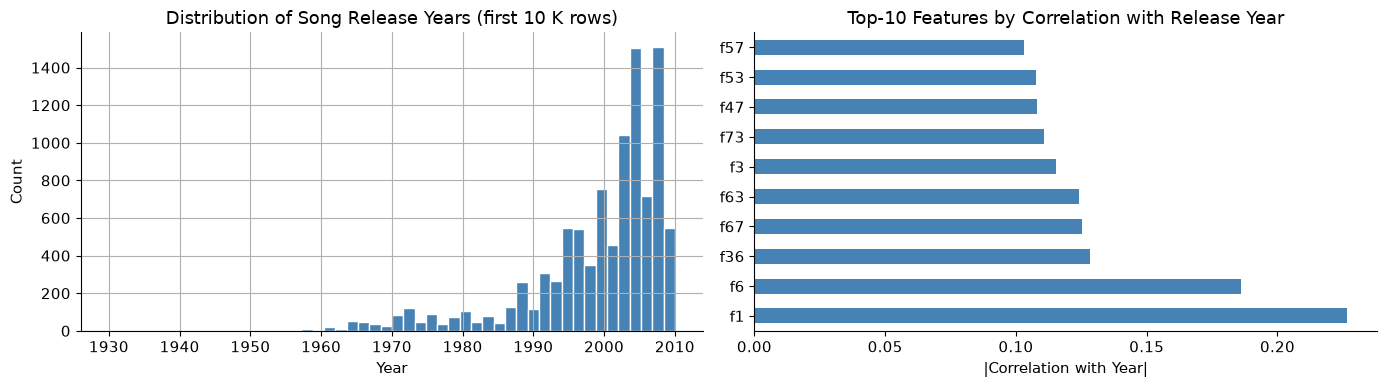

In [24]:
# Quick EDA — read a small slice so we don't load the full file
df_eda = pd.read_csv(MSD_DATA_FILE, header=None, nrows=10_000)
feature_cols = ['year'] + [f'f{i}' for i in range(1, 91)]
df_eda.columns = feature_cols

print(f'Sample shape: {df_eda.shape}')
print(f'Year range : {df_eda["year"].min()} – {df_eda["year"].max()}')
print(f'Year mean  : {df_eda["year"].mean():.1f}')
print(f'Year std   : {df_eda["year"].std():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eda['year'].hist(bins=50, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Song Release Years (first 10 K rows)')

corrs = df_eda.corr()['year'].drop('year').abs().sort_values(ascending=False).head(10)
corrs.plot(kind='barh', ax=axes[1], color=COLORS[0])
axes[1].set_xlabel('|Correlation with Year|')
axes[1].set_title('Top-10 Features by Correlation with Release Year')

plt.tight_layout()
plt.savefig('assets/msd_eda.png', dpi=120, bbox_inches='tight')
plt.show()


<a id='sgd'></a>
### 4.3 SGDRegressor and `partial_fit`

#### From Batch GD to Mini-Batch SGD

**Batch gradient descent** computes the gradient over *all* N training samples before each weight update:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{N} \sum_{i=1}^{N} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is exact but requires all data in memory and is slow for large N.

**Stochastic gradient descent (SGD)** uses a single random sample per update:  
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

**Mini-batch SGD** strikes a balance — use a small batch of B samples:
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{B} \sum_{i \in \text{batch}} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is both memory-efficient and statistically stable.

#### `partial_fit` in sklearn

`SGDRegressor.partial_fit(X_batch, y_batch)` applies **one pass** of mini-batch SGD on the provided batch without forgetting previously learned weights. Calling it repeatedly on successive batches (or even on multiple epochs over the same data) implements full online/incremental learning.

```python
sgd = SGDRegressor(learning_rate='constant', eta0=0.01)

for chunk in pd.read_csv('bigfile.csv', chunksize=50_000):
    X_chunk = chunk.iloc[:, 1:].values
    y_chunk = chunk.iloc[:, 0].values
    sgd.partial_fit(X_scaled, y_chunk)   # weights updated in-place
```

**Key rule**: the scaler must be fitted on **training data only** — never re-fitted on test data or future production chunks — then applied (`transform`) consistently everywhere. The cleanest approach (used in Exercise 2.1) is a dedicated first pass over **all** training chunks with `StandardScaler.partial_fit`, which gives accurate statistics regardless of dataset size. For datasets where two passes are prohibitively expensive, fitting on a **representative sample** (e.g. the first few chunks) is a common practical shortcut, provided the sample reflects the overall distribution.


---
<a id='ex21'></a>
### Exercise 2.1 — Implement the Mini-Batch Training Loop (Basic)

Implement one epoch of mini-batch SGD over the MSD training data using `SGDRegressor.partial_fit`.

**Tasks:**
1. Create an `SGDRegressor` with `loss='squared_error'`, `learning_rate='constant'`, `eta0=0.001`, `random_state=42`.
2. Create a `StandardScaler`.
3. **Pass 1 — fit the scaler**: stream through the training rows and call `msd_scaler.partial_fit(X_chunk)` on every chunk so the scaler captures the full training distribution.
4. **Pass 2 — train**: stream through the data again. For each chunk:
   - Extract `y_chunk` (column 0) and `X_chunk` (columns 1–90).
   - Transform `X_chunk` with the already-fitted scaler.
   - Call `sgd.partial_fit(X_scaled, y_chunk)`.
   - Compute RMSE on the current chunk (after the update) and store it in `chunk_rmses`.
5. Print the total number of chunks processed and the final chunk RMSE.

> **Practical note on scaler fitting**: Pass 1 here scans *all* training chunks with `partial_fit`, giving the most accurate mean and variance estimates — ideal when two passes are affordable. For very large datasets where two passes are too costly, fitting on a **representative sample** (e.g. the first chunk or a random subset) is an acceptable approximation, provided the sample is reasonably representative of the full distribution. In production streaming systems where the data distribution can shift over time (**concept drift**), consider periodically re-calling `partial_fit` on a recent window of data to keep the scaler's statistics fresh.

**Expected output**: With `CHUNK_SIZE = 5_000`, process 93 training chunks (92 full chunks and a final chunk of 3,715 songs). Report the measured final chunk RMSE; its value depends on the data and training settings. This is a training error on the last chunk, not an overall or test RMSE.


In [4]:
# One epoch on the official training split, streamed in chunks.
sgd = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.001,
    random_state=RANDOM_STATE,
)
msd_scaler = StandardScaler()

# Pass 1: accumulate scaling statistics from TRAINING rows only.
scaler_rows_seen = 0
with pd.read_csv(
    MSD_DATA_FILE, header=None,
    nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE,
) as training_chunks:
    for chunk in training_chunks:
        X_chunk = chunk.iloc[:, 1:].to_numpy(dtype=np.float64)
        msd_scaler.partial_fit(X_chunk)
        scaler_rows_seen += len(chunk)

assert scaler_rows_seen == MSD_TRAIN_ROWS
print(f'Pass 1: scaler fitted on {scaler_rows_seen:,} training songs.')

# Pass 2: keep the scaler fixed and update the SAME SGD model chunk by chunk.
chunk_rmses = []
chunk_sizes = []
with pd.read_csv(
    MSD_DATA_FILE, header=None,
    nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE,
) as training_chunks:
    for chunk_number, chunk in enumerate(training_chunks, start=1):
        y_chunk = chunk.iloc[:, 0].to_numpy(dtype=np.float64)
        X_chunk = chunk.iloc[:, 1:].to_numpy(dtype=np.float64)
        X_scaled = msd_scaler.transform(X_chunk)

        # One pass over these songs; internally SGD updates per observation.
        sgd.partial_fit(X_scaled, y_chunk)

        # Training error on this chunk AFTER its update, not validation/test RMSE.
        chunk_predictions = sgd.predict(X_scaled)
        chunk_rmse = np.sqrt(mean_squared_error(y_chunk, chunk_predictions))
        chunk_rmses.append(float(chunk_rmse))
        chunk_sizes.append(len(chunk))

        if chunk_number == 1 or chunk_number % 10 == 0:
            print(f'Chunk {chunk_number:3d}: RMSE = {chunk_rmse:.4f} years')

print(f'\nTraining songs processed: {sum(chunk_sizes):,}')
print(f'Total chunks processed: {len(chunk_rmses)}')
print(f'Last chunk size: {chunk_sizes[-1]:,} songs')
print(f'Final chunk RMSE: {chunk_rmses[-1]:.4f} years')
print(f'Learned coefficients: {len(sgd.coef_)} + intercept')


Pass 1: scaler fitted on 463,715 training songs.
Chunk   1: RMSE = 44.2414 years


Chunk  10: RMSE = 10.6954 years


Chunk  20: RMSE = 8.7459 years


Chunk  30: RMSE = 9.3001 years


Chunk  40: RMSE = 9.9681 years


Chunk  50: RMSE = 9.9605 years


Chunk  60: RMSE = 10.5371 years


Chunk  70: RMSE = 9.3523 years


Chunk  80: RMSE = 9.0193 years


Chunk  90: RMSE = 8.7198 years

Training songs processed: 463,715
Total chunks processed: 93
Last chunk size: 3,715 songs
Final chunk RMSE: 9.7518 years
Learned coefficients: 90 + intercept


**Reflexión**

Después de una época, el modelo ha actualizado sus coeficientes utilizando todo el conjunto de entrenamiento, pero esto no garantiza que haya convergido ni que sean los mejores coeficientes. Además, el último RMSE corresponde únicamente al bloque final, evaluado después de entrenar con él; no representa el error global ni la capacidad de generalización. Para evaluar el progreso y seleccionar un buen estado del modelo, debemos comparar su desempeño en un conjunto fijo de validación a lo largo de varias épocas.

---
<a id='ex22'></a>
### Exercise 2.2 — Plot the Convergence Curve (Basic)

Using the `chunk_rmses` list from Exercise 2.1, plot the RMSE as a function of chunk number to visualise convergence within one epoch.

**Tasks:**
1. Plot RMSE vs. chunk index.
2. Add axis labels and a title.
3. Answer: does the model converge within a single pass? What pattern do you observe?


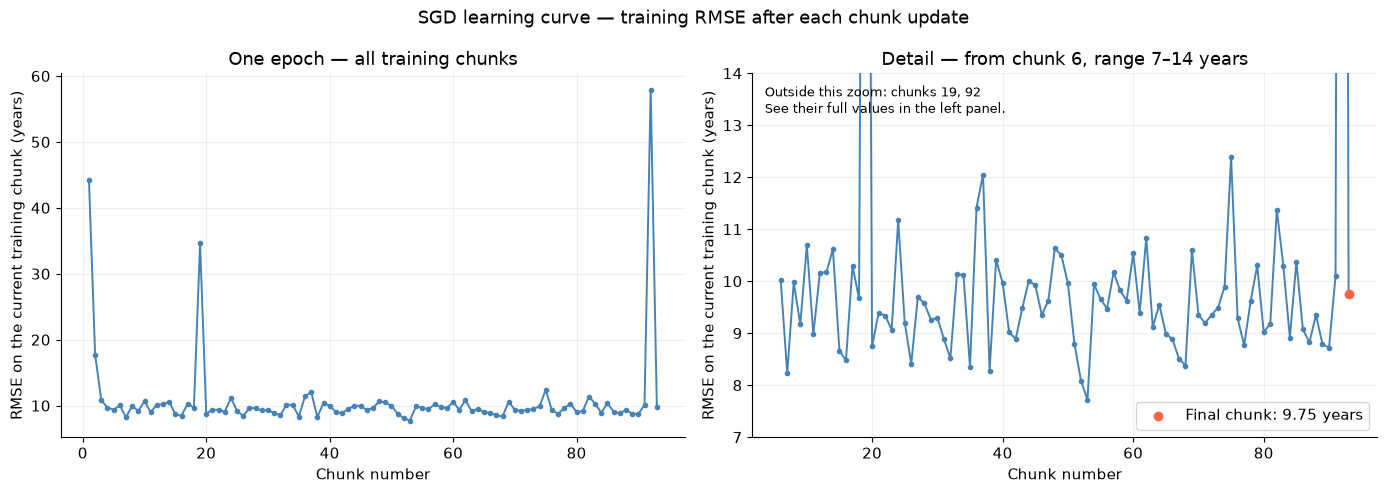

First chunk RMSE: 44.2414 years
Final chunk RMSE: 9.7518 years
Last 20 chunks — median RMSE: 9.4875 years
Last 20 chunks — RMSE range: 8.7198–57.9102 years
Each point evaluates a different training chunk after learning from it.

Estadísticos de todos los RMSE por bloque (años):
Cantidad de bloques                    93.0000
Media                                  10.8356
Desviación estándar (muestral)          6.7153
Mínimo                                  7.7227
Percentil 25                            9.0163
Mediana                                 9.5476
Percentil 75                           10.1711
Máximo                                 57.9102
Amplitud del rango (máximo - mínimo)   50.1875


In [8]:
# Reuse the errors from Exercise 2.1; this cell does not train the model.
chunk_numbers = np.arange(1, len(chunk_rmses) + 1)
rmse_values = np.asarray(chunk_rmses, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full curve: includes the initial learning phase.
axes[0].plot(chunk_numbers, rmse_values, color='steelblue',
             marker='o', markersize=3, linewidth=1.4)
axes[0].set_title('One epoch — all training chunks')
axes[0].set_xlabel('Chunk number')
axes[0].set_ylabel('RMSE on the current training chunk (years)')

# Detail: make later fluctuations visible without the large initial error.
detail_start = min(5, len(rmse_values) - 1)
axes[1].plot(chunk_numbers[detail_start:], rmse_values[detail_start:],
             color='steelblue', marker='o', markersize=3, linewidth=1.4)
axes[1].scatter(chunk_numbers[-1], rmse_values[-1], color='tomato', zorder=3,
                label=f'Final chunk: {rmse_values[-1]:.2f} years')
# Zoom the vertical axis only; the full curve at left retains every peak.
axes[1].set_ylim(7, 14)
axes[1].set_title(f'Detail — from chunk {detail_start + 1}, range 7–14 years')
clipped_chunks = chunk_numbers[detail_start:][
    (rmse_values[detail_start:] < 7) | (rmse_values[detail_start:] > 14)
]
if len(clipped_chunks):
    axes[1].text(0.02, 0.97,
                 'Outside this zoom: chunks ' + ', '.join(map(str, clipped_chunks))
                 + '\nSee their full values in the left panel.',
                 transform=axes[1].transAxes, va='top', fontsize=9)
axes[1].set_xlabel('Chunk number')
axes[1].set_ylabel('RMSE on the current training chunk (years)')
axes[1].legend(loc='lower right')

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle('SGD learning curve — training RMSE after each chunk update')
fig.tight_layout()
fig.savefig('assets/sgd_one_epoch_chunk_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# Keep the complete history for later inspection.
chunk_rmse_history = pd.DataFrame({
    'chunk': chunk_numbers,
    'rmse_years': rmse_values,
})
chunk_rmse_history.to_csv('assets/sgd_one_epoch_chunk_rmse.csv', index=False)

tail_count = min(20, len(rmse_values))
last_chunk_errors = rmse_values[-tail_count:]
print(f'First chunk RMSE: {rmse_values[0]:.4f} years')
print(f'Final chunk RMSE: {rmse_values[-1]:.4f} years')
print(f'Last {tail_count} chunks — median RMSE: {np.median(last_chunk_errors):.4f} years')
print(f'Last {tail_count} chunks — RMSE range: '
      f'{last_chunk_errors.min():.4f}–{last_chunk_errors.max():.4f} years')
print('Each point evaluates a different training chunk after learning from it.')

# Descriptive statistics across ALL chunk RMSEs (each chunk has equal weight).
rmse_stats = pd.Series(chunk_rmses, name='RMSE (years)').describe().rename(index={
    'count': 'Cantidad de bloques',
    'mean': 'Media',
    'std': 'Desviación estándar (muestral)',
    'min': 'Mínimo',
    '25%': 'Percentil 25',
    '50%': 'Mediana',
    '75%': 'Percentil 75',
    'max': 'Máximo',
})
rmse_stats.loc['Amplitud del rango (máximo - mínimo)'] = np.ptp(chunk_rmses)
print('\nEstadísticos de todos los RMSE por bloque (años):')
print(rmse_stats.to_string(float_format=lambda value: f'{value:.4f}'))


**Reflexión**

El error disminuye rápidamente al inicio: pasa de 44.24 años en el primer bloque a 10.82 en el tercero. Después, la mayoría de los bloques presenta un RMSE aproximadamente entre 8 y 12 años, pero hay picos de 34.60 y 57.91 años en los bloques 19 y 92. El bloque final registra 9.75 años.

La curva muestra una mejora inicial y fluctuaciones posteriores; no permite confirmar que los coeficientes hayan convergido en una sola época. Cada punto se calcula sobre un bloque diferente después de entrenar con él, por lo que las variaciones pueden reflejar tanto cambios del modelo como diferencias entre bloques. Para evaluar la convergencia y la generalización con mayor claridad, debemos seguir el error sobre un conjunto fijo de validación durante varias épocas. El panel derecho amplía el rango de 7 a 14 años; los picos completos se conservan en el panel izquierdo.


---
<a id='ex23'></a>
### Exercise 2.3 — Multi-Epoch Training (Intermediate)

One pass through the data is often insufficient. Run `N_EPOCHS` epochs and track **validation RMSE** on the held-out test set after each epoch.

**Tasks:**
1. Load the test set: `pd.read_csv(MSD_DATA_FILE, header=None, skiprows=MSD_TRAIN_ROWS)`. Scale X_test using the **already-fitted** scaler from Exercise 2.1 (`msd_scaler`).
2. Train a fresh `SGDRegressor` (same settings as 2.1) for `N_EPOCHS` epochs, recording both per-chunk train RMSE and per-epoch validation RMSE. **Shuffle the training data at the start of each epoch** so the model sees a different ordering every pass.
3. Plot train RMSE per chunk (all epochs concatenated) and validation RMSE per epoch on the same figure.
4. Answer: does validation RMSE improve across epochs? When does it saturate?


In [9]:
# Exercise 2.3: a fresh model, but the SAME fitted scaler from Exercise 2.1.
from pathlib import Path
from copy import deepcopy

assert int(msd_scaler.n_samples_seen_) == MSD_TRAIN_ROWS
msd_assets = Path('assets')
msd_assets.mkdir(exist_ok=True)

# Store scaled training features on disk for a GLOBAL shuffle each epoch.
# Only each CSV chunk and each selected training batch need to be copied into RAM.
msd_X_train_disk = np.lib.format.open_memmap(
    msd_assets / 'msd_train_scaled.npy', mode='w+', dtype=np.float64,
    shape=(MSD_TRAIN_ROWS, 90),
)
msd_y_train = np.empty(MSD_TRAIN_ROWS, dtype=np.float64)
offset = 0
with pd.read_csv(
    MSD_DATA_FILE, header=None, nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE,
) as training_chunks:
    for chunk in training_chunks:
        end = offset + len(chunk)
        msd_X_train_disk[offset:end] = msd_scaler.transform(
            chunk.iloc[:, 1:].to_numpy(dtype=np.float64)
        )
        msd_y_train[offset:end] = chunk.iloc[:, 0].to_numpy(dtype=np.float64)
        offset = end
assert offset == MSD_TRAIN_ROWS
msd_X_train_disk.flush()

# The exercise calls the official test split "validation".
# Use it only for evaluation here; never update the scaler or model with it.
msd_eval_frame = pd.read_csv(
    MSD_DATA_FILE, header=None, skiprows=MSD_TRAIN_ROWS, nrows=MSD_TEST_ROWS,
)
assert len(msd_eval_frame) == MSD_TEST_ROWS
msd_X_eval = msd_scaler.transform(
    msd_eval_frame.iloc[:, 1:].to_numpy(dtype=np.float64)
)
msd_y_eval = msd_eval_frame.iloc[:, 0].to_numpy(dtype=np.float64)
del msd_eval_frame

print(f'Training: {MSD_TRAIN_ROWS:,} songs; evaluation: {len(msd_y_eval):,} songs.')
print(f'Ready for {N_EPOCHS} epochs; globally shuffled rows each epoch.')
print('Evaluation uses the official test split, as requested by Exercise 2.3.')


Training: 463,715 songs; evaluation: 51,630 songs.
Fresh SGD model; 10 epochs; globally shuffled rows each epoch.
Evaluation uses the official test split, as requested by Exercise 2.3.


In [10]:
# Start fresh when this training cell runs; then keep the SAME model across epochs.
sgd_multi = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.001,
    random_state=RANDOM_STATE,
)
shuffle_rng = np.random.default_rng(RANDOM_STATE)
multi_chunk_records = []
multi_epoch_records = []
epoch_models = []
global_chunk = 0

for epoch in range(1, N_EPOCHS + 1):
    # Every training row appears exactly once, in a new global order.
    shuffled_rows = shuffle_rng.permutation(MSD_TRAIN_ROWS)
    epoch_rows_seen = 0

    for chunk_in_epoch, start in enumerate(
        range(0, MSD_TRAIN_ROWS, CHUNK_SIZE), start=1
    ):
        batch_rows = shuffled_rows[start:start + CHUNK_SIZE]
        X_batch_scaled = msd_X_train_disk[batch_rows]
        y_batch = msd_y_train[batch_rows]

        sgd_multi.partial_fit(X_batch_scaled, y_batch)
        batch_predictions = sgd_multi.predict(X_batch_scaled)
        train_chunk_rmse = np.sqrt(mean_squared_error(y_batch, batch_predictions))

        global_chunk += 1
        epoch_rows_seen += len(batch_rows)
        multi_chunk_records.append({
            'epoch': epoch,
            'chunk_in_epoch': chunk_in_epoch,
            'global_chunk': global_chunk,
            'n_songs': len(batch_rows),
            'train_chunk_rmse_years': float(train_chunk_rmse),
        })

    assert epoch_rows_seen == MSD_TRAIN_ROWS
    # These are the weights AFTER the LAST chunk of the current epoch.
    # predict performs no training, and the evaluation songs stay fixed.
    epoch_eval_predictions = sgd_multi.predict(msd_X_eval)
    epoch_validation_rmse = np.sqrt(
        mean_squared_error(msd_y_eval, epoch_eval_predictions)
    )
    multi_epoch_records.append({
        'epoch': epoch,
        'end_global_chunk': global_chunk,
        'validation_rmse_years': float(epoch_validation_rmse),
    })
    # Keep a separate snapshot of each epoch, not ten references to one object.
    epoch_models.append(deepcopy(sgd_multi))

    # Persist both histories after every completed epoch.
    multi_chunk_history = pd.DataFrame(multi_chunk_records)
    multi_epoch_history = pd.DataFrame(multi_epoch_records)
    multi_chunk_history.to_csv(msd_assets / 'sgd_multi_chunk_rmse.csv', index=False)
    multi_epoch_history.to_csv(msd_assets / 'sgd_multi_epoch_rmse.csv', index=False)
    print(f'Epoch {epoch:2d}/{N_EPOCHS}: {chunk_in_epoch} chunks; '
          f'evaluation RMSE = {epoch_validation_rmse:.4f} years')

# Save fitted objects too, so plots and inspection do not require retraining.
from joblib import dump
dump({
    'scaler': msd_scaler,
    'final_model': sgd_multi,
    'epoch_models': epoch_models,
    'chunk_history': multi_chunk_history,
    'epoch_history': multi_epoch_history,
}, msd_assets / 'sgd_multi_epoch_results.joblib')

print('\nEnd-of-epoch evaluation on the same official test split:')
print(multi_epoch_history[['epoch', 'validation_rmse_years']].to_string(
    index=False, float_format=lambda value: f'{value:.4f}'
))


Epoch  1/10: 93 chunks; evaluation RMSE = 9.9274 years


Epoch  2/10: 93 chunks; evaluation RMSE = 10.0818 years


Epoch  3/10: 93 chunks; evaluation RMSE = 10.0053 years


Epoch  4/10: 93 chunks; evaluation RMSE = 9.8727 years


Epoch  5/10: 93 chunks; evaluation RMSE = 9.8559 years


Epoch  6/10: 93 chunks; evaluation RMSE = 9.9298 years


Epoch  7/10: 93 chunks; evaluation RMSE = 10.3874 years


Epoch  8/10: 93 chunks; evaluation RMSE = 9.7426 years


Epoch  9/10: 93 chunks; evaluation RMSE = 9.7712 years


Epoch 10/10: 93 chunks; evaluation RMSE = 9.8436 years

End-of-epoch evaluation on the same official test split:
 epoch  validation_rmse_years
     1                 9.9274
     2                10.0818
     3                10.0053
     4                 9.8727
     5                 9.8559
     6                 9.9298
     7                10.3874
     8                 9.7426
     9                 9.7712
    10                 9.8436


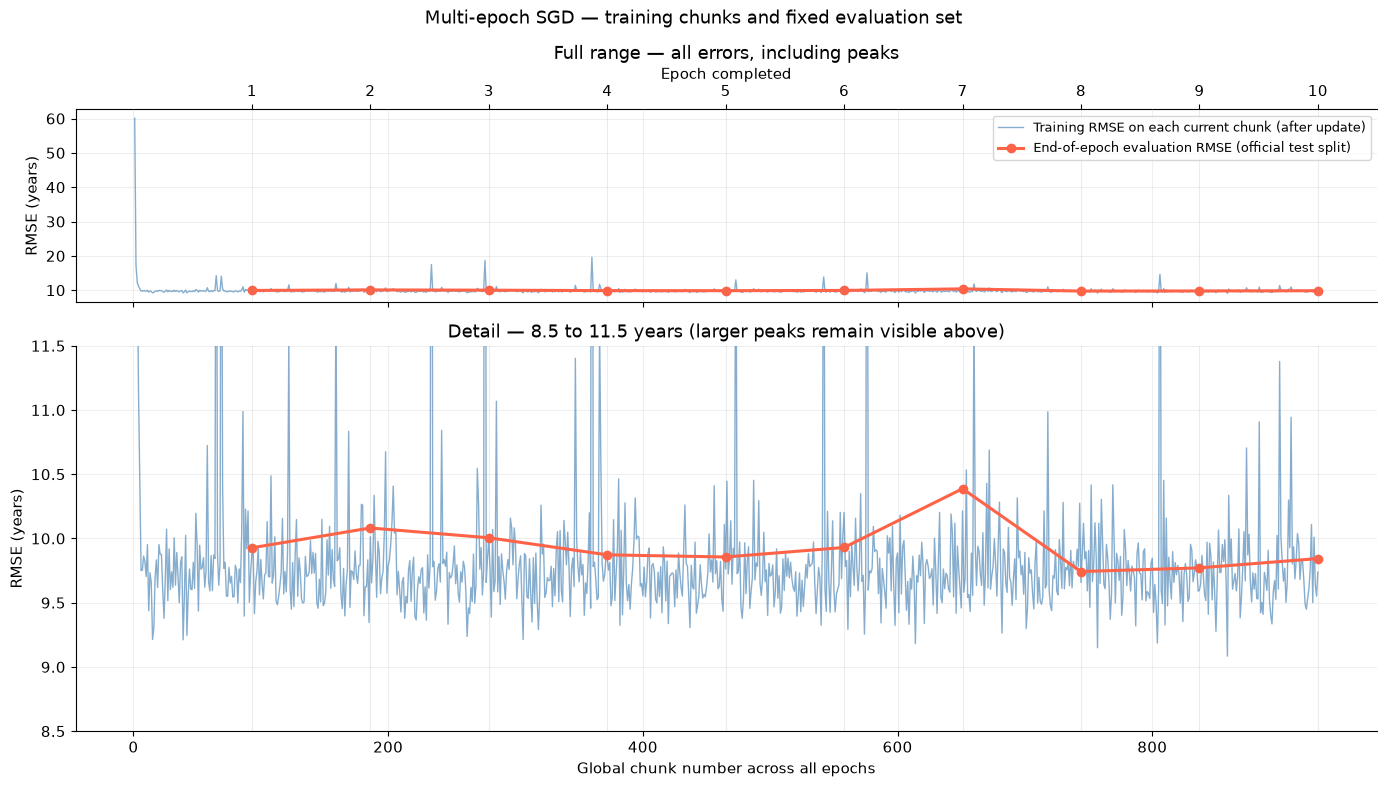

In [12]:
# Both series use the same x-axis: chunks concatenated across epochs.
# Each evaluation point is placed at the LAST chunk of its epoch.
fig, axes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]},
)
for ax in axes:
    ax.plot(
        multi_chunk_history['global_chunk'],
        multi_chunk_history['train_chunk_rmse_years'],
        color='steelblue', alpha=0.65, linewidth=1,
        label='Training RMSE on each current chunk (after update)',
    )
    ax.plot(
        multi_epoch_history['end_global_chunk'],
        multi_epoch_history['validation_rmse_years'],
        color='tomato', marker='o', linewidth=2.2,
        label='End-of-epoch evaluation RMSE (official test split)',
    )
    for boundary in multi_epoch_history['end_global_chunk']:
        ax.axvline(boundary, color='gray', alpha=0.15, linewidth=0.8)
    ax.set_ylabel('RMSE (years)')
    ax.grid(alpha=0.2)

axes[0].set_title('Full range — all errors, including peaks')
axes[0].legend(loc='upper right', fontsize=9)
axes[1].set_ylim(8.5, 11.5)
axes[1].set_title('Detail — 8.5 to 11.5 years (larger peaks remain visible above)')
axes[1].set_xlabel('Global chunk number across all epochs')
epoch_axis = axes[0].secondary_xaxis('top')
epoch_axis.set_xticks(
    multi_epoch_history['end_global_chunk'],
    labels=multi_epoch_history['epoch'].astype(str),
)
epoch_axis.set_xlabel('Epoch completed')
fig.suptitle('Multi-epoch SGD — training chunks and fixed evaluation set')
fig.tight_layout()
fig.savefig(msd_assets / 'sgd_multi_epoch_rmse.png', dpi=150, bbox_inches='tight')
plt.show()


**Reflexión — ejercicio 2.3:** Después de cada época se evalúa el modelo con los coeficientes obtenidos al terminar su último bloque, sobre las mismas 51,630 canciones reservadas. El modelo continúa aprendiendo entre épocas; no se reinicia en cada una.

El RMSE de validación pasa de 9.9274 años en la primera época a 9.8436 en la décima, una reducción aproximada del 0.84 %. No disminuye de forma monótona: oscila entre 9.7426 y 10.3874 años. El menor valor observado corresponde a la época 8. Los resultados sugieren una meseta temprana alrededor de 10 años, con fluctuaciones posteriores; no permiten identificar una época exacta de convergencia ni garantizan haber encontrado los mejores coeficientes.

Se guardan 930 errores de entrenamiento por bloque y 10 errores de evaluación al cierre de las épocas, además de los diez modelos correspondientes. Como pide el ejercicio, el conjunto de validación es el **test oficial**, denominado “validación” en el ejercicio. Si se usa esta curva para seleccionar épocas o hiperparámetros, ese conjunto deja de ser una evaluación final independiente. Deberiamos tener un conjunto oficial de test que no se use en validación.


---
<a id='ex24'></a>
### Exercise 2.4 — Learning Rate Exploration (Key Exercise)

The learning rate `eta0` is the most sensitive hyperparameter in SGD. Too large, and gradient updates overshoot the minimum, causing **divergence**. Too small, and learning is too slow to be practical.

**Tasks:**
1. Train five separate `SGDRegressor` models, each with a different `eta0` from `[0.0001, 0.001, 0.01, 0.1, 1.0]`, each for **one epoch** over the training data.
2. For each model, track per-chunk RMSE. If RMSE becomes `NaN` or `inf`, stop training that model early and mark it as diverged.
3. Plot all five convergence curves on the same axes. Cap the y-axis at 150 years so diverging runs don't dominate.
4. Answer the following:
   - Which learning rates diverge?
   - Why does a large learning rate cause divergence? Sketch the geometry.
   - What is the cost of using too small a learning rate?


In [13]:
# One fresh model per learning rate; same scaler, rows, chunks and random seed.
from pathlib import Path
from joblib import dump

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
assert int(msd_scaler.n_samples_seen_) == MSD_TRAIN_ROWS
lr_models = {
    eta: SGDRegressor(
        loss='squared_error', learning_rate='constant', eta0=eta,
        shuffle=True, random_state=RANDOM_STATE,
    )
    for eta in learning_rates
}
# shuffle=True also applied in 2.1: each model uses the same seeded within-chunk order.
# There is no extra global permutation; all models receive identical CSV chunks.
lr_stopped = {eta: False for eta in learning_rates}
lr_stop_reason = {eta: '' for eta in learning_rates}
lr_records = []
lr_rows_seen = 0

with pd.read_csv(
    MSD_DATA_FILE, header=None, nrows=MSD_TRAIN_ROWS, chunksize=CHUNK_SIZE,
) as training_chunks:
    for chunk_number, chunk in enumerate(training_chunks, start=1):
        X_lr = msd_scaler.transform(chunk.iloc[:, 1:].to_numpy(dtype=np.float64))
        y_lr = chunk.iloc[:, 0].to_numpy(dtype=np.float64)
        lr_rows_seen += len(chunk)
        for eta, model in lr_models.items():
            if lr_stopped[eta]:
                continue
            try:
                with np.errstate(over='ignore', invalid='ignore'):
                    model.partial_fit(X_lr, y_lr)
                    predictions = model.predict(X_lr)
                    rmse = float(np.sqrt(np.mean((y_lr - predictions) ** 2)))
                if not np.isfinite(rmse):
                    lr_stopped[eta] = True
                    lr_stop_reason[eta] = 'Non-finite RMSE (NaN/inf)'
            except ValueError as error:
                # sklearn can detect numerical overflow before predict is reached.
                if not any(word in str(error).lower() for word in ('overflow', 'infinity', 'nan', 'non-finite')):
                    raise
                rmse = float('nan')
                lr_stopped[eta] = True
                lr_stop_reason[eta] = str(error)
            lr_records.append({
                'eta0': eta, 'chunk': chunk_number,
                'n_songs': len(chunk), 'train_rmse_years': rmse,
            })
            if lr_stopped[eta]:
                print(f'eta0={eta:g}: stopped at chunk {chunk_number}: {lr_stop_reason[eta]}')
        if chunk_number == 1 or chunk_number % 20 == 0:
            print(f'Processed chunk {chunk_number}; same songs for all active models.')
        if all(lr_stopped.values()):
            break

lr_history = pd.DataFrame(lr_records)
lr_summary_rows = []
for eta in learning_rates:
    history = lr_history.loc[lr_history['eta0'] == eta]
    finite_errors = history.loc[np.isfinite(history['train_rmse_years']), 'train_rmse_years']
    lr_summary_rows.append({
        'eta0': eta,
        'chunks_attempted': len(history),
        'last_chunk_rmse': history['train_rmse_years'].iloc[-1],
        'min_chunk_rmse': finite_errors.min(),
        'max_chunk_rmse': finite_errors.max(),
        'stopped_nonfinite': lr_stopped[eta],
    })
lr_summary = pd.DataFrame(lr_summary_rows)
Path('assets').mkdir(exist_ok=True)
lr_history.to_csv('assets/sgd_learning_rate_chunk_rmse.csv', index=False)
lr_summary.to_csv('assets/sgd_learning_rate_summary.csv', index=False)
dump({'models': lr_models, 'scaler': msd_scaler, 'history': lr_history,
      'summary': lr_summary, 'stop_reasons': lr_stop_reason},
     'assets/sgd_learning_rate_results.joblib')
print('\nTraining RMSE in years (last chunk is NOT full-training or test RMSE):')
print(lr_summary.to_string(index=False, float_format=lambda x: f'{x:.6g}'))
print('Finite but enormous errors can also indicate unstable/diverging learning.')


Processed chunk 1; same songs for all active models.


Processed chunk 20; same songs for all active models.


Processed chunk 40; same songs for all active models.


Processed chunk 60; same songs for all active models.


Processed chunk 80; same songs for all active models.



Training RMSE in years (last chunk is NOT full-training or test RMSE):
  eta0  chunks_attempted  last_chunk_rmse  min_chunk_rmse  max_chunk_rmse  stopped_nonfinite
0.0001                93          9.43962         7.80088         1194.26              False
 0.001                93          9.75183         7.72266         57.9102              False
  0.01                93      1.84211e+11      3.9597e+09     3.71026e+12              False
   0.1                93      5.21111e+12     3.81812e+12      3.5282e+13              False
     1                93        5.784e+13     4.48612e+13     3.50119e+14              False
Finite but enormous errors can also indicate unstable/diverging learning.


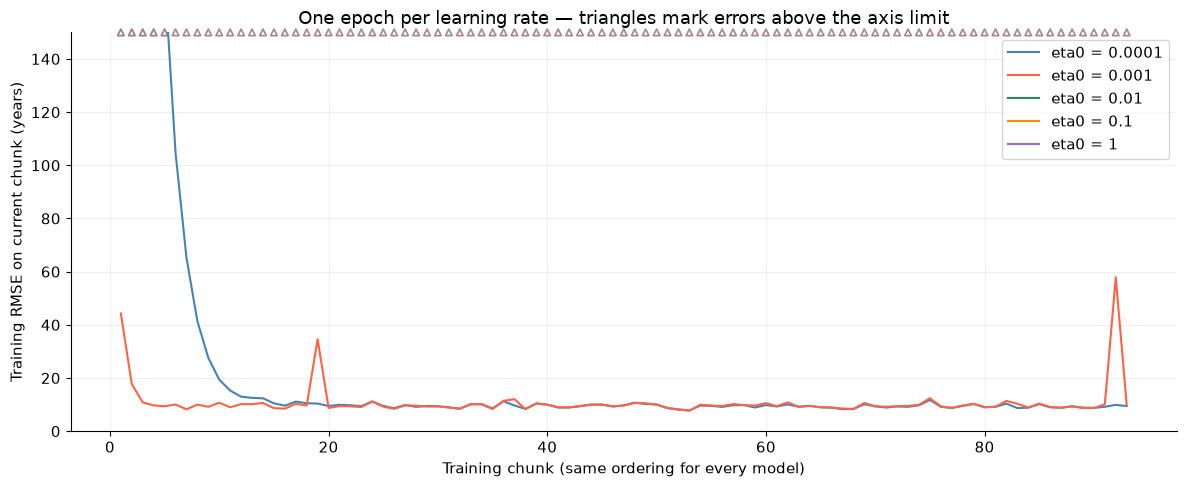

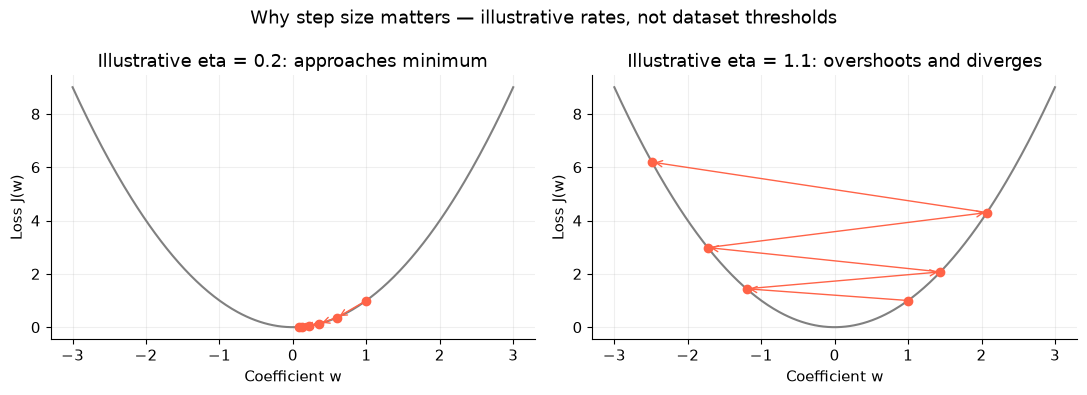

In [14]:
# Requested comparison: all five curves, with the vertical axis capped at 150.
fig, ax = plt.subplots(figsize=(12, 5))
for eta, color in zip(learning_rates, COLORS):
    history = lr_history.loc[lr_history['eta0'] == eta]
    errors = history['train_rmse_years'].to_numpy()
    chunks = history['chunk'].to_numpy()
    label = f'eta0 = {eta:g}'
    if lr_stopped[eta]:
        label += ' (stopped: non-finite)'
    ax.plot(chunks, errors, color=color, linewidth=1.5, label=label)
    # Marks at the ceiling mean the real value is OUTSIDE the displayed range.
    outside = (errors > 150) | ~np.isfinite(errors)
    if outside.any():
        ax.scatter(chunks[outside], np.full(outside.sum(), 150.0),
                   marker='^', s=22, facecolors='none', edgecolors=color,
                   clip_on=False, alpha=0.6)
ax.set_ylim(0, 150)
ax.set_xlabel('Training chunk (same ordering for every model)')
ax.set_ylabel('Training RMSE on current chunk (years)')
ax.set_title('One epoch per learning rate — triangles mark errors above the axis limit')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig('assets/sgd_learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Geometric illustration only: a one-coefficient quadratic, not the music model.
# J(w)=w**2, dJ/dw=2*w, so w_next=(1-2*eta)*w.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
w_grid = np.linspace(-3, 3, 300)
for ax, eta in zip(axes, [0.2, 1.1]):
    trajectory = [1.0]
    for step in range(5):
        trajectory.append((1 - 2 * eta) * trajectory[-1])
    ax.plot(w_grid, w_grid**2, color='gray', label='J(w) = w²')
    ax.scatter(trajectory, np.square(trajectory), color='tomato', zorder=3)
    for start, end in zip(trajectory[:-1], trajectory[1:]):
        ax.annotate('', xy=(end, end**2), xytext=(start, start**2),
                    arrowprops={'arrowstyle': '->', 'color': 'tomato'})
    ax.set_title(f'Illustrative eta = {eta}: ' + ('approaches minimum' if eta < 1 else 'overshoots and diverges'))
    ax.set_xlabel('Coefficient w')
    ax.set_ylabel('Loss J(w)')
    ax.grid(alpha=0.2)
fig.suptitle('Why step size matters — illustrative rates, not dataset thresholds')
fig.tight_layout()
fig.savefig('assets/sgd_learning_rate_geometry.png', dpi=150, bbox_inches='tight')
plt.show()


**Reflexión**

Los cinco modelos se entrenaron desde cero durante una época, con el mismo scaler, los mismos bloques en el orden original y la misma semilla. Se mantuvo el barajado interno de cada bloque (`shuffle=True`) del ejercicio 2.1; no se aplicó un barajado global adicional. La única configuración que cambió fue `eta0`, manteniendo `learning_rate='constant'`.

Las tasas `0.01`, `0.1` y `1.0` produjeron errores enormes, compatibles con un aprendizaje inestable o divergente. Ningún RMSE llegó a `NaN` o infinito, por lo que los cinco modelos completaron los 93 bloques. Un error finito no garantiza que el entrenamiento sea estable. Los triángulos en el borde superior de la gráfica indican valores fuera del rango mostrado; no representan errores iguales a 150 años.

Una tasa demasiado grande hace que las actualizaciones sobrepasen el mínimo y puedan alejarse de él. En la ilustración, para $J(w)=w^2$, la actualización es $w_{t+1}=(1-2\eta)w_t$. Con $\eta=0.2$, los pesos se acercan a cero; con $\eta=1.1$, alternan de signo y crecen en magnitud. Estas tasas son ilustrativas: el límite de estabilidad depende de la curvatura de la función de pérdida y no es el mismo para todos los problemas.

Con `eta0=0.0001`, el primer bloque todavía tiene un RMSE de aproximadamente 1194 años: los pasos pequeños tardan más en ajustar el modelo desde su inicio. Al terminar, el RMSE del último bloque es 9.4396 años, frente a 9.7518 con `eta0=0.001`. Este resultado corresponde solamente al último bloque de entrenamiento; no demuestra que `0.0001` generalice mejor. Una tasa pequeña puede necesitar más actualizaciones y más tiempo de entrenamiento para alcanzar un error útil.


---
<a id='ex25'></a>
### Exercise 2.5 — Learning Rate Schedules (Advanced)

A fixed learning rate is a compromise: large enough to converge quickly, small enough to avoid divergence. **Learning rate schedules** decay the rate over time, allowing fast initial progress and fine-grained convergence later.

sklearn's `SGDRegressor` supports several built-in schedules via `learning_rate`:

| Schedule | Formula | Notes |
|----------|---------|-------|
| `'constant'` | `η = eta0` | Fixed; need to tune eta0 |
| `'optimal'` | `η_t = 1 / (α (t + t₀))` | Auto-calculated; ignores eta0 |
| `'invscaling'` | `η_t = eta0 / t^power_t` | Polynomial decay; flexible |

**Tasks:**
1. Train three models for 3 epochs each: `learning_rate='constant'` (eta0=0.001), `learning_rate='optimal'`, and `learning_rate='invscaling'` (eta0=0.001, power_t=0.25).
2. After each epoch, record the validation RMSE on the test set.
3. Plot validation RMSE vs. epoch for all three schedules.
4. Answer: which schedule reaches the lowest validation RMSE? What is the trade-off between `constant` and decaying schedules in the context of streaming data (where the data distribution may shift over time)?


In [15]:
# Exercise 2.5: fresh SGD models; reuse the TRAINING-only scaler/data from 2.3.
from pathlib import Path
from copy import deepcopy
from joblib import dump

SCHEDULE_EPOCHS = 3  # Leave N_EPOCHS for Exercise 2.3 unchanged.
assert int(msd_scaler.n_samples_seen_) == MSD_TRAIN_ROWS
assert msd_X_train_disk.shape == (MSD_TRAIN_ROWS, 90)
assert len(msd_y_train) == MSD_TRAIN_ROWS
assert len(msd_y_eval) == MSD_TEST_ROWS

schedule_models = {
    name: SGDRegressor(
        loss='squared_error', penalty='l2', alpha=0.0001,
        learning_rate=name, eta0=0.001, power_t=0.25,
        shuffle=True, random_state=RANDOM_STATE,
    )
    for name in ['constant', 'optimal', 'invscaling']
}
# optimal ignores eta0; it computes its rate using alpha and its own initial offset.
# Keep each model alive for all epochs: weights AND the learning-rate counter carry on.
schedule_rng = np.random.default_rng(RANDOM_STATE)
schedule_chunk_records = []
schedule_epoch_records = []
schedule_snapshots = {name: [] for name in schedule_models}
schedule_failures = {}
schedule_global_chunk = 0

for epoch in range(1, SCHEDULE_EPOCHS + 1):
    # One new permutation per epoch, SHARED by all three models.
    schedule_order = schedule_rng.permutation(MSD_TRAIN_ROWS)
    epoch_rows_seen = 0
    for chunk_in_epoch, start in enumerate(
        range(0, MSD_TRAIN_ROWS, CHUNK_SIZE), start=1,
    ):
        batch_rows = schedule_order[start:start + CHUNK_SIZE]
        X_schedule = msd_X_train_disk[batch_rows]
        y_schedule = msd_y_train[batch_rows]
        schedule_global_chunk += 1
        epoch_rows_seen += len(batch_rows)
        for name, model in schedule_models.items():
            if name in schedule_failures:
                continue
            try:
                with np.errstate(over='ignore', invalid='ignore'):
                    model.partial_fit(X_schedule, y_schedule)
                    error = model.predict(X_schedule) - y_schedule
                    train_rmse = float(np.sqrt(np.mean(error ** 2)))
                if not np.isfinite(train_rmse):
                    schedule_failures[name] = 'Non-finite training RMSE'
            except ValueError as error:
                if not any(word in str(error).lower() for word in ('overflow', 'infinity', 'nan', 'non-finite')):
                    raise
                train_rmse = float('nan')
                schedule_failures[name] = str(error)
            schedule_chunk_records.append({
                'schedule': name, 'epoch': epoch, 'chunk_in_epoch': chunk_in_epoch,
                'global_chunk': schedule_global_chunk, 'n_songs': len(batch_rows),
                'train_chunk_rmse_years': train_rmse,
            })
    assert epoch_rows_seen == MSD_TRAIN_ROWS

    # Evaluate the SAME official test songs with each model's end-of-epoch weights.
    # These predictions do not update the scaler, the weights, or the rate counter.
    for name, model in schedule_models.items():
        test_rmse = float('nan')
        if name not in schedule_failures:
            with np.errstate(over='ignore', invalid='ignore'):
                test_error = model.predict(msd_X_eval) - msd_y_eval
                test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
            if not np.isfinite(test_rmse):
                schedule_failures[name] = 'Non-finite test RMSE'
            schedule_snapshots[name].append(deepcopy(model))
        schedule_epoch_records.append({
            'schedule': name, 'epoch': epoch,
            'end_global_chunk': schedule_global_chunk,
            'test_rmse_years': test_rmse,
        })
        print(f'Epoch {epoch}/{SCHEDULE_EPOCHS} | {name:10s} | test RMSE: {test_rmse:.6g} years')

schedule_chunk_history = pd.DataFrame(schedule_chunk_records)
schedule_epoch_history = pd.DataFrame(schedule_epoch_records)
schedule_test_table = schedule_epoch_history.pivot(
    index='epoch', columns='schedule', values='test_rmse_years',
).reindex(columns=list(schedule_models))
Path('assets').mkdir(exist_ok=True)
schedule_chunk_history.to_csv('assets/sgd_schedule_chunk_rmse.csv', index=False)
schedule_epoch_history.to_csv('assets/sgd_schedule_epoch_rmse.csv', index=False)
dump({
    'models': schedule_models, 'scaler': msd_scaler,
    'epoch_models': schedule_snapshots, 'chunk_history': schedule_chunk_history,
    'epoch_history': schedule_epoch_history, 'failures': schedule_failures,
}, 'assets/sgd_schedule_results.joblib')
print('\nEnd-of-epoch test RMSE (years):')
print(schedule_test_table.to_string(float_format=lambda x: f'{x:.6g}'))
print('\nChunk RMSE records per model:')
print(schedule_chunk_history.groupby('schedule').size().to_string())
if schedule_failures:
    print('Numerical failures:', schedule_failures)


Epoch 1/3 | constant   | test RMSE: 9.92736 years
Epoch 1/3 | optimal    | test RMSE: 7.3524e+11 years
Epoch 1/3 | invscaling | test RMSE: 9.53998 years


Epoch 2/3 | constant   | test RMSE: 10.0818 years
Epoch 2/3 | optimal    | test RMSE: 4.33686e+11 years
Epoch 2/3 | invscaling | test RMSE: 9.5282 years


Epoch 3/3 | constant   | test RMSE: 10.0053 years
Epoch 3/3 | optimal    | test RMSE: 2.18708e+10 years
Epoch 3/3 | invscaling | test RMSE: 9.51406 years

End-of-epoch test RMSE (years):
schedule  constant     optimal  invscaling
epoch                                     
1          9.92736  7.3524e+11     9.53998
2          10.0818 4.33686e+11      9.5282
3          10.0053 2.18708e+10     9.51406

Chunk RMSE records per model:
schedule
constant      279
invscaling    279
optimal       279


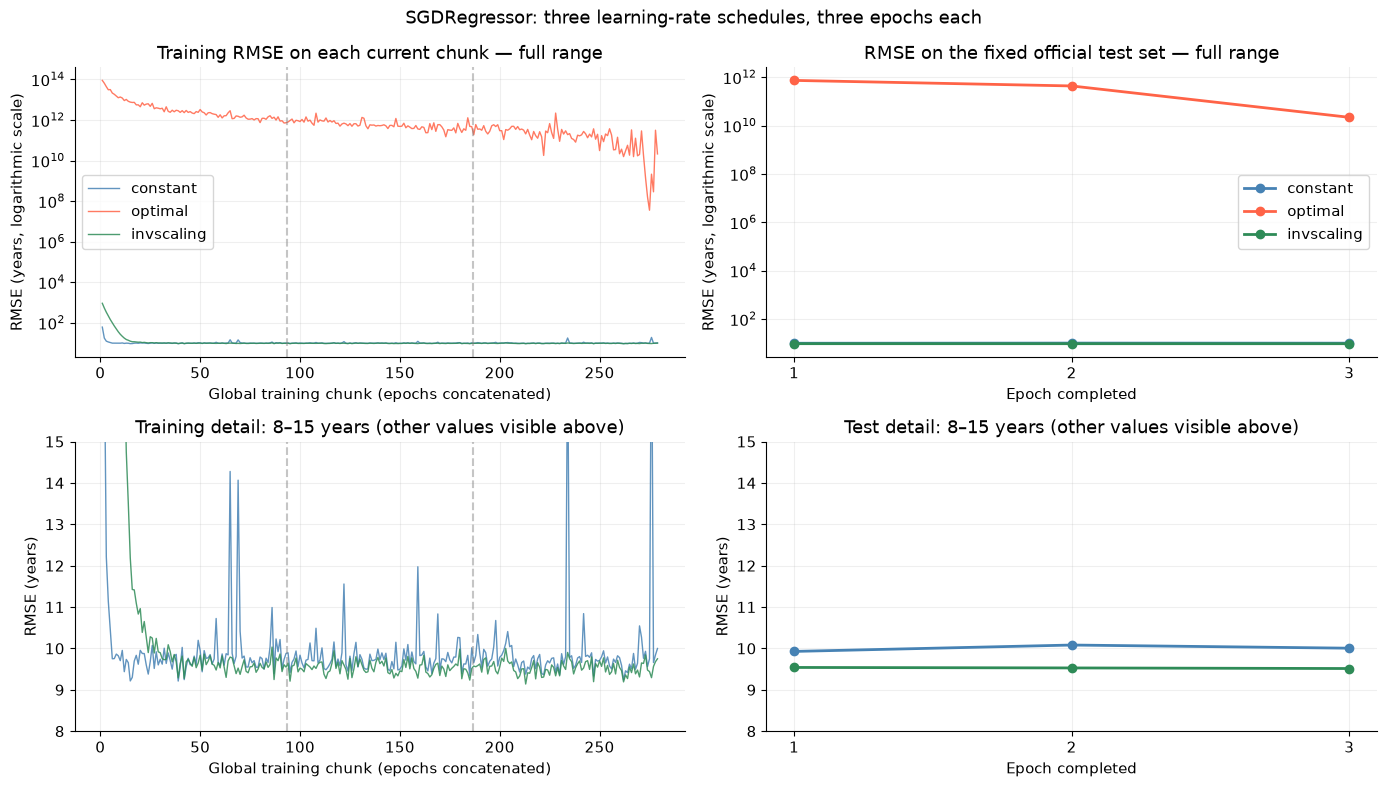

In [16]:
# Training curves have 279 points/model; fixed-test curves have 3 points/model.
# Full-range logarithmic panels keep even very large finite errors visible.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
schedule_colors = dict(zip(schedule_models, ['steelblue', 'tomato', 'seagreen']))
for name, color in schedule_colors.items():
    train = schedule_chunk_history.loc[schedule_chunk_history['schedule'] == name]
    test = schedule_epoch_history.loc[schedule_epoch_history['schedule'] == name]
    for row in range(2):
        axes[row, 0].plot(train['global_chunk'], train['train_chunk_rmse_years'],
                          color=color, linewidth=1, alpha=0.85, label=name)
        axes[row, 1].plot(test['epoch'], test['test_rmse_years'],
                          color=color, marker='o', linewidth=2, label=name)

for ax in axes[0]:
    ax.set_yscale('log')
    ax.set_ylabel('RMSE (years, logarithmic scale)')
    ax.legend()
# Explicit zoom panels allow comparison of the errors near ten years.
for ax in axes[1]:
    ax.set_ylim(8, 15)
    ax.set_ylabel('RMSE (years)')
for ax in axes[:, 0]:
    for epoch_end in [93, 186]:
        ax.axvline(epoch_end + 0.5, color='gray', linestyle='--', alpha=0.45)
    ax.set_xlabel('Global training chunk (epochs concatenated)')
for ax in axes[:, 1]:
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Epoch completed')
for ax in axes.flat:
    ax.grid(alpha=0.2)
axes[0, 0].set_title('Training RMSE on each current chunk — full range')
axes[0, 1].set_title('RMSE on the fixed official test set — full range')
axes[1, 0].set_title('Training detail: 8–15 years (other values visible above)')
axes[1, 1].set_title('Test detail: 8–15 years (other values visible above)')
fig.suptitle('SGDRegressor: three learning-rate schedules, three epochs each')
fig.tight_layout()
fig.savefig('assets/sgd_schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**Reflexión** 

Se entrenaron tres `SGDRegressor` nuevos durante tres épocas cada uno, reutilizando el scaler ajustado exclusivamente con entrenamiento y la semilla 42. En cada época se generó una nueva permutación global, compartida por los tres modelos. También se mantuvo el mismo barajado interno de los bloques. Cada modelo conservó sus pesos y el contador de actualizaciones entre bloques y épocas; solo cambió el esquema de learning rate.

Se guardaron **279 RMSE de entrenamiento por modelo** (93 bloques por época) y **3 RMSE sobre el test oficial por modelo**. La primera curva muestra el error sobre cada bloque después de entrenarlo; la segunda compara los coeficientes de fin de época sobre las mismas 51,630 canciones. Los errores por bloques aportan detalle, pero no sustituyen la evaluación sobre un conjunto fijo.

`invscaling` obtuvo el menor RMSE de test en las tres épocas, con 9.5400, 9.5282 y 9.5141 años. `constant` obtuvo 9.9274, 10.0818 y 10.0053 años. Con estos ajustes, `optimal` produjo errores enormes (aproximadamente 7.35e11, 4.34e11 y 2.19e10 años); aunque disminuyeron, el modelo no alcanzó un resultado útil. El nombre del esquema no garantiza que sea apropiado para este dataset. En `optimal`, `eta0` se ignora: la tasa depende de `alpha` y del contador de actualizaciones, por lo que su tasa inicial no coincide necesariamente con 0.001.

Una tasa constante mantiene la capacidad de realizar ajustes ante datos nuevos, pero puede sostener fluctuaciones alrededor de una buena solución. Una tasa decreciente puede reducir esas fluctuaciones cuando la distribución es estable; si la distribución de los datos cambia con el tiempo, una tasa que ya se volvió muy pequeña puede dificultar la adaptación. Este experimento no simula un cambio de distribución, así que no demuestra cuál sería mejor en ese escenario.

El test oficial se usa como validación siguiendo el enunciado. Si elegimos el esquema a partir de estos resultados, este conjunto participa en la selección y ya no constituye una prueba final independiente como se mencionó antes.


---
<a id='realworld'></a>
## 5. Real-World Considerations

### When to Use Batch vs. Online Learning

| Scenario | Recommendation |
|----------|----------------|
| Data fits in memory, static | Batch (Ridge/Lasso + Pipeline + GridSearchCV) |
| Data too large for RAM | Online (`SGDRegressor.partial_fit` on chunks) |
| Continuous data stream (concept drift) | Online with constant or slowly decaying LR |
| Periodic retraining on large archive | Mini-batch SGD or distributed frameworks (Spark MLlib, Dask-ML) |

### Practical Tips for SGD in Production

**Always scale features.** SGD is sensitive to feature scale; unscaled inputs can cause gradients to differ by orders of magnitude across features, making tuning nearly impossible. Fit the scaler once on a representative sample (or the first chunk) and apply it consistently.

**Monitor for divergence early.** Add a check after the first few chunks: if RMSE is not decreasing or is NaN, stop and reduce `eta0` by a factor of 10.

**Regularization matters even more for SGD.** With noisy mini-batch gradients, models can overfit if run for many epochs without regularization. Use `penalty='l2'` (default) with a non-zero `alpha` in `SGDRegressor`.

**Warm-starting scaler for streaming data.** If your data distribution shifts over time, consider re-fitting the scaler periodically (e.g., every N chunks) or using `StandardScaler` with `partial_fit` to update statistics incrementally.

**Evaluation on held-out data.** The per-chunk train RMSE is noisy (gradient descent is still mid-step). Always evaluate on a separately held-out test set for a reliable performance estimate.

### Pipelines Are Not Directly Compatible with `partial_fit`

sklearn's `Pipeline` object does not support `partial_fit` in all configurations — specifically, you cannot call `pipeline.partial_fit()` if the pipeline contains transformers that need to be fitted incrementally. The typical workaround (as implemented above) is to manage the scaler manually outside the loop and feed pre-scaled chunks to the SGD estimator.


---
<a id='summary'></a>
## 6. Summary and Key Takeaways

### Part 1 — Pipelines and Regularization

- **Pipelines** chain preprocessing and modeling steps into a single object that integrates cleanly with `cross_val_score` and `GridSearchCV`, preventing data leakage.
- **Polynomial features** extend a linear model's capacity to capture non-linear relationships. The expansion is controlled by `degree`; higher degrees increase variance and require stronger regularization.
- **Ridge regression** adds an L2 penalty to the OLS loss: `min ‖Xw − y‖² + α‖w‖²`. It is always uniquely solvable and numerically stable, even with many correlated features.
- **GridSearchCV** evaluates each candidate α using k-fold CV and returns the optimal value. The validation curve shows the classic U-shape: decreasing CV error as α grows (fighting overfitting), then increasing error as α becomes too large (causing underfitting).
- **Lasso** (L1) promotes sparsity — many coefficients become exactly zero — making it useful for feature selection when interpretability matters.

### Part 2 — Online Learning with SGD

- **Mini-batch SGD** updates model weights on small chunks of data without ever loading the full dataset. It is the standard approach for datasets that exceed available RAM or for continuously arriving data.
- **`SGDRegressor.partial_fit`** incrementally updates weights without resetting them. Call it repeatedly on successive chunks or multiple epochs to approximate full-batch training.
- **The learning rate is critical.** Too large → gradient updates overshoot the loss minimum → divergence. Too small → convergence is impractically slow. The `'optimal'` schedule or a constant rate around `eta0 = 0.01` is a good starting point for standardized features.
- **Decaying schedules** (`invscaling`) are good for static datasets but can become too conservative for streaming data with concept drift; prefer `constant` or `optimal` in those settings.

